In [ ]:
import numpy as np
import librosa

# y and sr already loaded from previous cell

# Extract all features
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
rms       = librosa.feature.rms(y=y)[0]
spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
onset_det = librosa.onset.onset_detect(y=y, sr=sr)
chroma    = librosa.feature.chroma_stft(y=y, sr=sr)
mfcc      = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
y_h, y_p  = librosa.effects.hpss(y)
harm_rms  = librosa.feature.rms(y=y_h)[0]
perc_rms  = librosa.feature.rms(y=y_p)[0]

# Derived
note_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
dom_note   = note_names[np.argmax(chroma.mean(axis=1))]
duration   = len(y) / sr
n_pts      = min(len(rms), len(spec_cent), len(onset_env))

def norm(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn) if mx != mn else np.zeros_like(arr)

tension = norm(rms[:n_pts]) * 0.4 + norm(spec_cent[:n_pts]) * 0.3 + norm(onset_env[:n_pts]) * 0.3

print(f"Tempo          : {float(tempo):.1f} BPM")
print(f"Dominant note  : {dom_note}")
print(f"Duration       : {duration:.1f}s")
print(f"Mean RMS       : {rms.mean():.4f}")
print(f"Mean brightness: {spec_cent.mean():.1f} Hz")
print(f"Total onsets   : {len(onset_det)}")
print(f"Onset rate     : {len(onset_det)/duration:.2f} /sec")
print(f"Harmonic ratio : {harm_rms.mean()/(harm_rms.mean()+perc_rms.mean()):.3f}")
print(f"Mean tension   : {tension.mean():.4f}")

Tempo          : 66.3 BPM
Dominant note  : A#
Duration       : 112.2s
Mean RMS       : 0.0459
Mean brightness: 991.7 Hz
Total onsets   : 144
Onset rate     : 1.28 /sec
Harmonic ratio : 0.888
Mean tension   : 0.1312


In [ ]:
from scipy import stats
from scipy.interpolate import interp1d
import sys
import os
import pandas as pd

# Normalize tension to 20 time points
from scipy.interpolate import interp1d

def norm_resample(arr, n=20):
    t   = np.linspace(0, 1, len(arr))
    t_c = np.linspace(0, 1, n)
    mn, mx = arr.min(), arr.max()
    arr_n  = (arr - mn) / (mx - mn) if mx != mn else np.zeros(len(arr))
    return interp1d(t, arr_n, bounds_error=False, fill_value='extrapolate')(t_c)

n = 20
audio_ts = {
    'rms'    : norm_resample(rms[:n_pts], n),
    'spec'   : norm_resample(spec_cent[:n_pts], n),
    'onset'  : norm_resample(onset_env[:n_pts], n),
    'harm'   : norm_resample(harm_rms[:n_pts], n),
    'tension': norm_resample(tension, n),
}

# Load physiology for the matching participant/piece
physio_folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\range_3324350-datatype_4096-1006\record_308166'

sys.path.insert(0, physio_folder)
import load_hx_data
load_hx_data.set_device_model('hx')

def load_phys_wav(fname, lo, hi, n=20):
    path = os.path.join(physio_folder, fname)
    if not os.path.exists(path):
        print(f"[MISSING] {fname}")
        return None
    df   = pd.DataFrame(load_hx_data.load_wave(path), columns=['time','val'])
    vals = df['val'].to_numpy()
    time = df['time'].to_numpy()
    if vals.mean() > 1000:
        vals = vals / 1000
    mask = (vals >= lo) & (vals <= hi)
    if mask.sum() < 3:
        return None
    return norm_resample(vals[mask], n)

phys_ts = {
    'heart_rate'     : load_phys_wav('heart_rate.wav', 30, 220, n),
    'breathing_rate' : load_phys_wav('breathing_rate.wav', 2, 60, n),
    'tidal_volume'   : load_phys_wav('tidal_volume.wav', 0, 5000, n),
}
phys_ts = {k: v for k, v in phys_ts.items() if v is not None}
print(f"Loaded physiology: {list(phys_ts.keys())}")

# Correlate
print(f"\n{'='*55}")
print(f"  AUDIO vs PHYSIOLOGY CORRELATION")
print(f"{'='*55}")
print(f"  {'Audio':<15} {'Physio':<20} {'r':>8} {'p':>8} {'Sig':>6}")
print(f"  {'-'*52}")

for af, a_vals in audio_ts.items():
    for pf, p_vals in phys_ts.items():
        r, p = stats.pearsonr(a_vals, p_vals)
        sig  = 'YES *' if p < 0.05 else 'no'
        print(f"  {af:<15} {pf:<20} {r:>8.4f} {p:>8.4f} {sig:>6}")

Loaded physiology: ['heart_rate', 'breathing_rate', 'tidal_volume']

  AUDIO vs PHYSIOLOGY CORRELATION
  Audio           Physio                      r        p    Sig
  ----------------------------------------------------
  rms             heart_rate             0.3149   0.1763     no
  rms             breathing_rate         0.0259   0.9136     no
  rms             tidal_volume          -0.4095   0.0730     no
  spec            heart_rate             0.0473   0.8431     no
  spec            breathing_rate         0.1515   0.5238     no
  spec            tidal_volume           0.2848   0.2236     no
  onset           heart_rate            -0.1005   0.6734     no
  onset           breathing_rate        -0.3162   0.1744     no
  onset           tidal_volume           0.0472   0.8432     no
  harm            heart_rate             0.3075   0.1873     no
  harm            breathing_rate         0.0125   0.9582     no
  harm            tidal_volume          -0.4084   0.0738     no
  tension 


[STEP 1] Extracting audio features from P2_video1_IMG1195.mp3
  Tempo=67.1BPM  Key=A#  Tension=0.194

[STEP 2] Loading physiological time series
  Loaded: ['heart_rate', 'breathing_rate', 'tidal_volume']

[STEP 3] Level 1 - Summary correlations

  LEVEL 1 - SUMMARY CORRELATION (per piece averages)
  Physio          Audio                       r        p    Sig
  ----------------------------------------------------------

[STEP 4] Level 2 - Time series correlations

  LEVEL 2 - TIME SERIES CORRELATION
  Audio           Physio                      r        p    Sig
  ----------------------------------------------------------
  rms             heart_rate             0.2909   0.2134     no
  rms             breathing_rate        -0.0142   0.9527     no
  rms             tidal_volume          -0.4007   0.0800     no
  spec            heart_rate             0.0801   0.7371     no
  spec            breathing_rate         0.1234   0.6043     no
  spec            tidal_volume           0.2476 

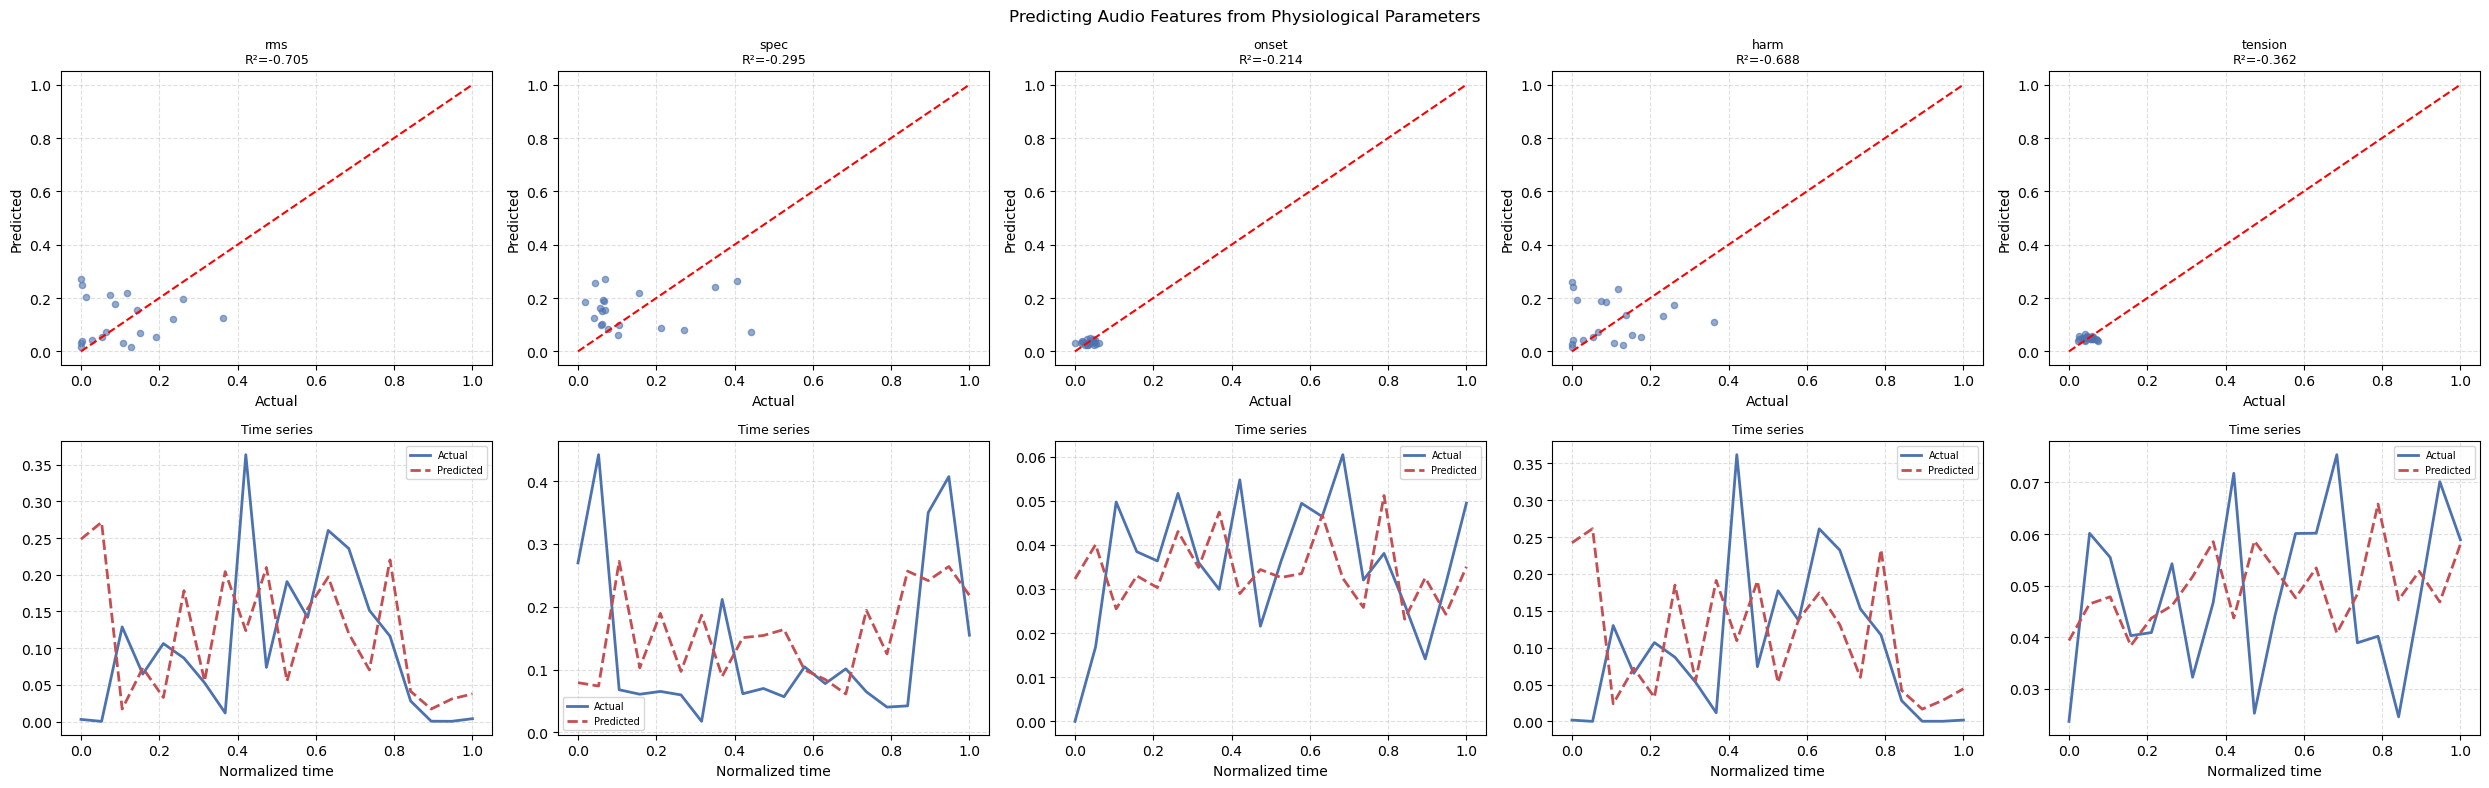

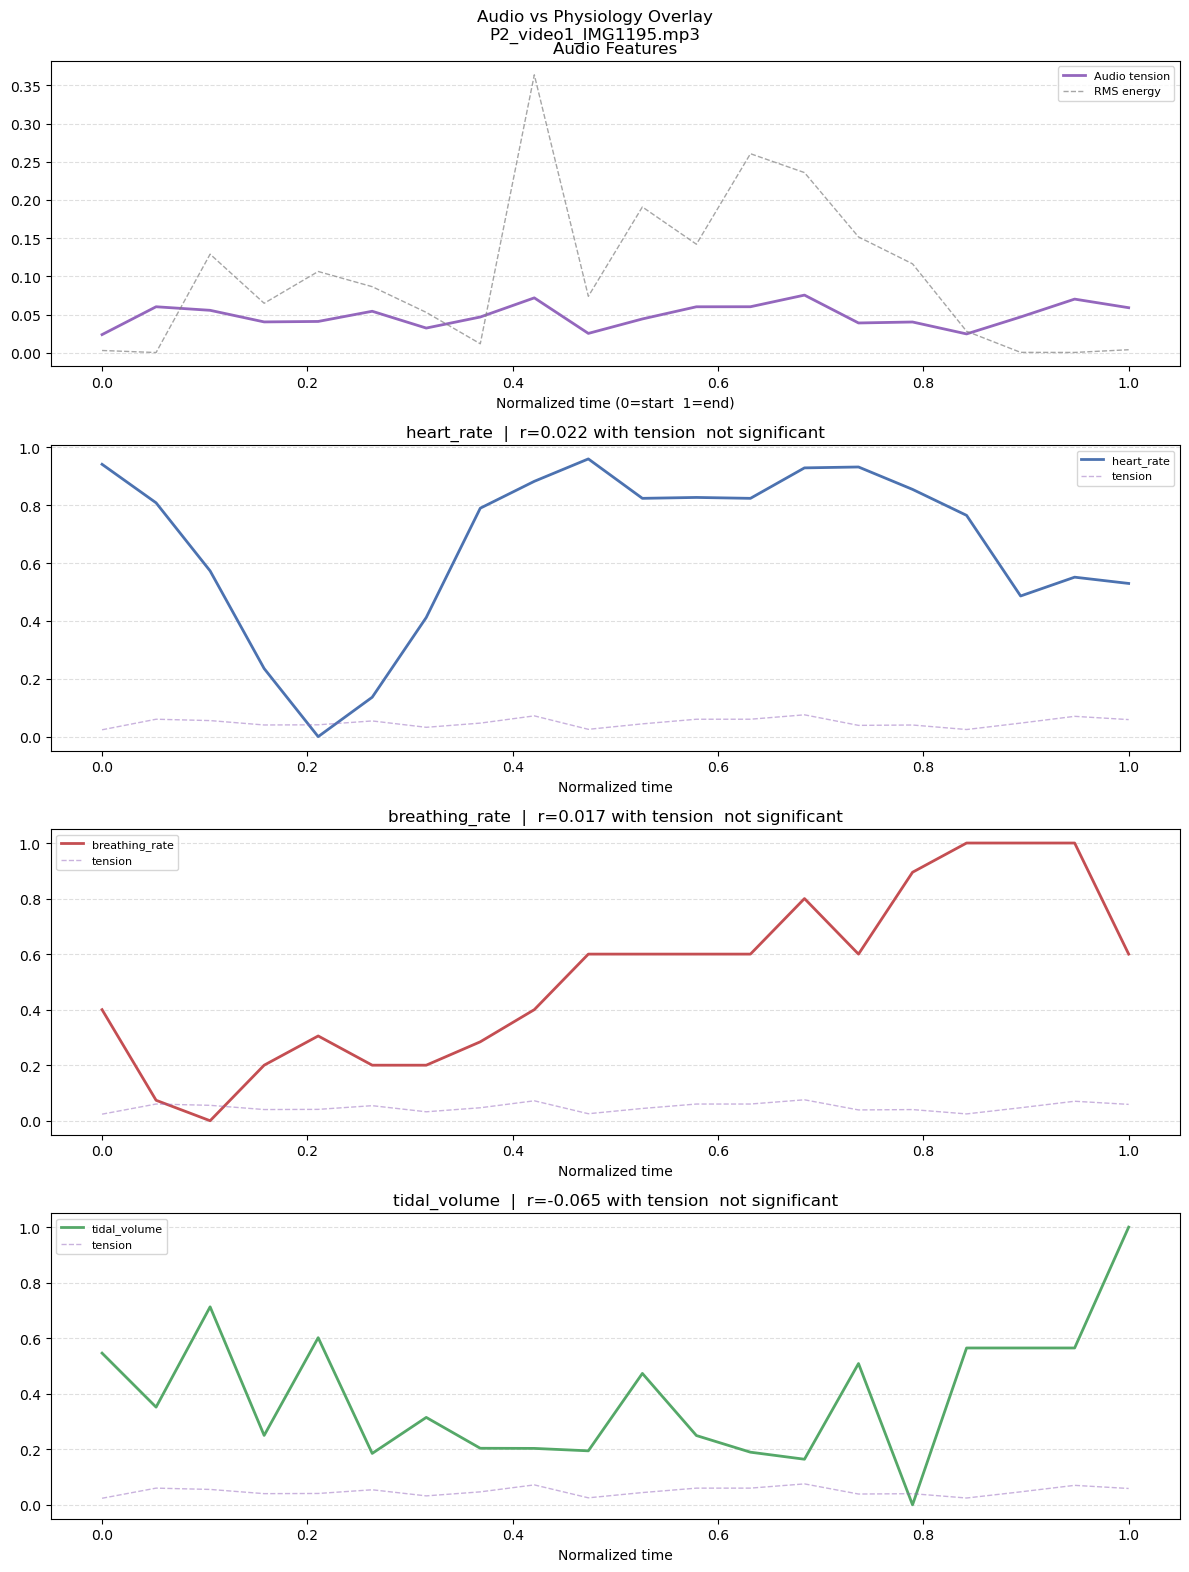

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from scipy import stats
from scipy.interpolate import interp1d
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


def norm_resample(arr, n=20):
    """Normalize to 0-1 and resample to n points."""
    t   = np.linspace(0, 1, len(arr))
    t_c = np.linspace(0, 1, n)
    mn, mx = arr.min(), arr.max()
    arr_n  = (arr - mn) / (mx - mn) if mx != mn else np.zeros(len(arr))
    return interp1d(t, arr_n, bounds_error=False, fill_value='extrapolate')(t_c)


def extract_audio_features(audio_path, n=20):
    """Extract summary stats and time series from audio."""
    y, sr    = librosa.load(audio_path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    rms      = librosa.feature.rms(y=y)[0]
    spec     = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    onset    = librosa.onset.onset_strength(y=y, sr=sr)
    y_h, _   = librosa.effects.hpss(y)
    harm     = librosa.feature.rms(y=y_h)[0]
    chroma   = librosa.feature.chroma_stft(y=y, sr=sr)
    dom_note = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B'][
                np.argmax(chroma.mean(axis=1))]
    n_pts    = min(len(rms), len(spec), len(onset), len(harm))
    tension  = rms[:n_pts]*0.4 + norm_resample(spec[:n_pts], n_pts)*0.3 + onset[:n_pts]*0.3

    summary = {
        'duration_s'   : round(duration, 1),
        'tempo_bpm'    : round(float(tempo), 1),
        'dominant_note': dom_note,
        'mean_rms'     : round(float(rms.mean()), 4),
        'std_rms'      : round(float(rms.std()), 4),
        'mean_brightness': round(float(spec.mean()), 1),
        'mean_tension' : round(float(tension.mean()), 4),
        'onset_rate'   : round(len(librosa.onset.onset_detect(y=y, sr=sr)) / duration, 3),
        'harmonic_ratio': round(float(harm.mean() / (harm.mean() + librosa.feature.rms(
                          y=librosa.effects.hpss(y)[1])[0].mean())), 3),
    }
    timeseries = {
        'rms'    : norm_resample(rms[:n_pts], n),
        'spec'   : norm_resample(spec[:n_pts], n),
        'onset'  : norm_resample(onset[:n_pts], n),
        'harm'   : norm_resample(harm[:n_pts], n),
        'tension': norm_resample(tension, n),
    }
    return summary, timeseries


def level1_summary_correlation(hrv_csv, audio_summaries):
    """Level 1 - correlate summary HRV stats with summary audio features."""
    hrv_df = pd.read_csv(hrv_csv)
    hrv_df['piece'] = hrv_df.groupby('participant_id')['range_folder'].rank(
                      method='first').astype(int)

    # Average HRV per piece across all participants
    hrv_mean = hrv_df.groupby('piece')[['RMSSD','pNN50','SD1_SD2_ratio']].mean()

    audio_df = pd.DataFrame(audio_summaries).T
    audio_df.index = range(1, len(audio_df)+1)
    audio_df = audio_df.apply(pd.to_numeric, errors='ignore')

    merged   = hrv_mean.join(audio_df, how='inner')
    phys_f   = ['RMSSD', 'pNN50', 'SD1_SD2_ratio']
    audio_f  = [c for c in audio_df.columns if audio_df[c].dtype in [float, np.float64]]

    print(f"\n{'='*60}")
    print(f"  LEVEL 1 - SUMMARY CORRELATION (per piece averages)")
    print(f"{'='*60}")
    print(f"  {'Physio':<15} {'Audio':<20} {'r':>8} {'p':>8} {'Sig':>6}")
    print(f"  {'-'*58}")

    results = []
    for pf in phys_f:
        for af in audio_f:
            if pf not in merged or af not in merged:
                continue
            vals = merged[[pf, af]].dropna()
            if len(vals) < 3:
                continue
            r, p = stats.pearsonr(vals[pf], vals[af])
            sig  = 'YES *' if p < 0.05 else 'no'
            print(f"  {pf:<15} {af:<20} {r:>8.4f} {p:>8.4f} {sig:>6}")
            results.append({'physio': pf, 'audio': af, 'r': r, 'p': p})

    return pd.DataFrame(results)


def level2_timeseries_correlation(audio_ts_dict, phys_ts_dict):
    """Level 2 - correlate time series of audio and physiology per piece."""
    audio_f = ['rms', 'spec', 'onset', 'harm', 'tension']
    phys_f  = list(phys_ts_dict.keys())
    results = []

    print(f"\n{'='*60}")
    print(f"  LEVEL 2 - TIME SERIES CORRELATION")
    print(f"{'='*60}")
    print(f"  {'Audio':<15} {'Physio':<20} {'r':>8} {'p':>8} {'Sig':>6}")
    print(f"  {'-'*58}")

    for af in audio_f:
        for pf in phys_f:
            if af not in audio_ts_dict or pf not in phys_ts_dict:
                continue
            a, p_arr = audio_ts_dict[af], phys_ts_dict[pf]
            if a is None or p_arr is None:
                continue
            r, p = stats.pearsonr(a, p_arr)
            sig  = 'YES *' if p < 0.05 else 'no'
            print(f"  {af:<15} {pf:<20} {r:>8.4f} {p:>8.4f} {sig:>6}")
            results.append({'audio': af, 'physio': pf, 'r': r, 'p': p})

    return pd.DataFrame(results)


def level3_prediction(audio_ts_dict, phys_ts_dict):
    """Level 3 - predict audio features from physiological parameters."""
    phys_f  = [k for k, v in phys_ts_dict.items() if v is not None]
    audio_f = [k for k, v in audio_ts_dict.items() if v is not None]

    if len(phys_f) < 2:
        print("[WARN] Not enough physiological features for prediction")
        return

    X = np.column_stack([phys_ts_dict[f] for f in phys_f])
    X = StandardScaler().fit_transform(X)

    print(f"\n{'='*60}")
    print(f"  LEVEL 3 - PREDICTING AUDIO FROM PHYSIOLOGY")
    print(f"{'='*60}")
    print(f"  {'Target':<20} {'R²':>8} {'MAE':>8} {'Quality':>12}")
    print(f"  {'-'*50}")

    pred_results = {}
    for af in audio_f:
        y      = audio_ts_dict[af]
        rf     = RandomForestRegressor(n_estimators=50, random_state=42)
        kf     = KFold(n_splits=min(5, len(y)), shuffle=True, random_state=42)
        y_pred = cross_val_predict(rf, X, y, cv=kf)
        r2     = r2_score(y, y_pred)
        mae    = mean_absolute_error(y, y_pred)
        qual   = 'Good' if r2 > 0.5 else 'Moderate' if r2 > 0.3 else 'Weak'
        print(f"  {af:<20} {r2:>8.4f} {mae:>8.4f} {qual:>12}")
        pred_results[af] = {'r2': r2, 'mae': mae, 'y': y, 'y_pred': y_pred}

    # Plot predictions
    n_plots = len(audio_f)
    fig, axes = plt.subplots(2, n_plots, figsize=(5*n_plots, 8))
    if n_plots == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle('Predicting Audio Features from Physiological Parameters', fontsize=12)

    t = np.linspace(0, 1, len(list(pred_results.values())[0]['y']))

    for i, af in enumerate(audio_f):
        res = pred_results[af]
        # Scatter
        axes[0, i].scatter(res['y'], res['y_pred'], alpha=0.6, s=20, color='#4C72B0')
        axes[0, i].plot([0,1],[0,1],'r--',linewidth=1.5)
        axes[0, i].set_title(f'{af}\nR²={res["r2"]:.3f}', fontsize=9)
        axes[0, i].set_xlabel('Actual')
        axes[0, i].set_ylabel('Predicted')
        axes[0, i].grid(linestyle='--', alpha=0.4)
        # Time series
        axes[1, i].plot(t, res['y'], color='#4C72B0', linewidth=2, label='Actual')
        axes[1, i].plot(t, res['y_pred'], color='#C44E52', linewidth=2,
                        linestyle='--', label='Predicted')
        axes[1, i].set_title('Time series', fontsize=9)
        axes[1, i].set_xlabel('Normalized time')
        axes[1, i].legend(fontsize=7)
        axes[1, i].grid(linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
    return pred_results


def run_full_analysis(audio_path, physio_folder, hrv_csv, piece_number=1):
    """Run all 3 levels of audio-physiology correlation."""
    import sys
    sys.path.insert(0, physio_folder)
    import load_hx_data
    load_hx_data.set_device_model('hx')

    def load_wav(fname, lo, hi, n=20):
        path = os.path.join(physio_folder, fname)
        if not os.path.exists(path):
            return None
        df   = pd.DataFrame(load_hx_data.load_wave(path), columns=['time','val'])
        vals = df['val'].to_numpy()
        time = df['time'].to_numpy()
        if vals.mean() > 1000:
            vals = vals / 1000
        mask = (vals >= lo) & (vals <= hi)
        if mask.sum() < 3:
            return None
        return norm_resample(vals[mask], n)

    n = 20
    print(f"\n[STEP 1] Extracting audio features from {os.path.basename(audio_path)}")
    audio_summary, audio_ts = extract_audio_features(audio_path, n)
    print(f"  Tempo={audio_summary['tempo_bpm']}BPM  "
          f"Key={audio_summary['dominant_note']}  "
          f"Tension={audio_summary['mean_tension']:.3f}")

    print(f"\n[STEP 2] Loading physiological time series")
    phys_ts = {
        'heart_rate'     : load_wav('heart_rate.wav', 30, 220, n),
        'breathing_rate' : load_wav('breathing_rate.wav', 2, 60, n),
        'tidal_volume'   : load_wav('tidal_volume.wav', 0, 5000, n),
    }
    phys_ts = {k: v for k, v in phys_ts.items() if v is not None}
    print(f"  Loaded: {list(phys_ts.keys())}")

    print(f"\n[STEP 3] Level 1 - Summary correlations")
    level1_summary_correlation(hrv_csv, {f'piece{piece_number}': audio_summary})

    print(f"\n[STEP 4] Level 2 - Time series correlations")
    corr_df = level2_timeseries_correlation(audio_ts, phys_ts)

    print(f"\n[STEP 5] Level 3 - Prediction")
    pred_results = level3_prediction(audio_ts, phys_ts)

    # Final overlay plot
    fig, axes = plt.subplots(len(phys_ts)+1, 1, figsize=(12, 4*(len(phys_ts)+1)))
    fig.suptitle(f'Audio vs Physiology Overlay\n{os.path.basename(audio_path)}',
                 fontsize=12)
    t = np.linspace(0, 1, n)
    colors = ['#4C72B0','#C44E52','#55A868','#DD8452']

    axes[0].plot(t, audio_ts['tension'], color='#9467BD', linewidth=2, label='Audio tension')
    axes[0].plot(t, audio_ts['rms'],     color='gray',    linewidth=1,
                 linestyle='--', label='RMS energy', alpha=0.7)
    axes[0].set_title('Audio Features')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)
    axes[0].set_xlabel('Normalized time (0=start  1=end)')

    for ax, (pf, pv), color in zip(axes[1:], phys_ts.items(), colors):
        r, p = stats.pearsonr(audio_ts['tension'], pv)
        ax.plot(t, pv,                  color=color,   linewidth=2, label=pf)
        ax.plot(t, audio_ts['tension'], color='#9467BD', linewidth=1,
                linestyle='--', alpha=0.5, label='tension')
        ax.set_title(f'{pf}  |  r={r:.3f} with tension  '
                     f'{"significant *" if p<0.05 else "not significant"}')
        ax.legend(fontsize=8)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.set_xlabel('Normalized time')

    plt.tight_layout()
    plt.show()

    return audio_summary, corr_df, pred_results


if __name__ == '__main__':
    audio_path    = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\2inspire_audio\audio\P2_video1_IMG1195.mp3'
    physio_folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\range_3324350-datatype_4096-1006\record_308166'
    hrv_csv       = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\hrv_metrics_all_participants.csv'

    audio_summary, corr_df, pred_results = run_full_analysis(
        audio_path    = audio_path,
        physio_folder = physio_folder,
        hrv_csv       = hrv_csv,
        piece_number  = 1
    )

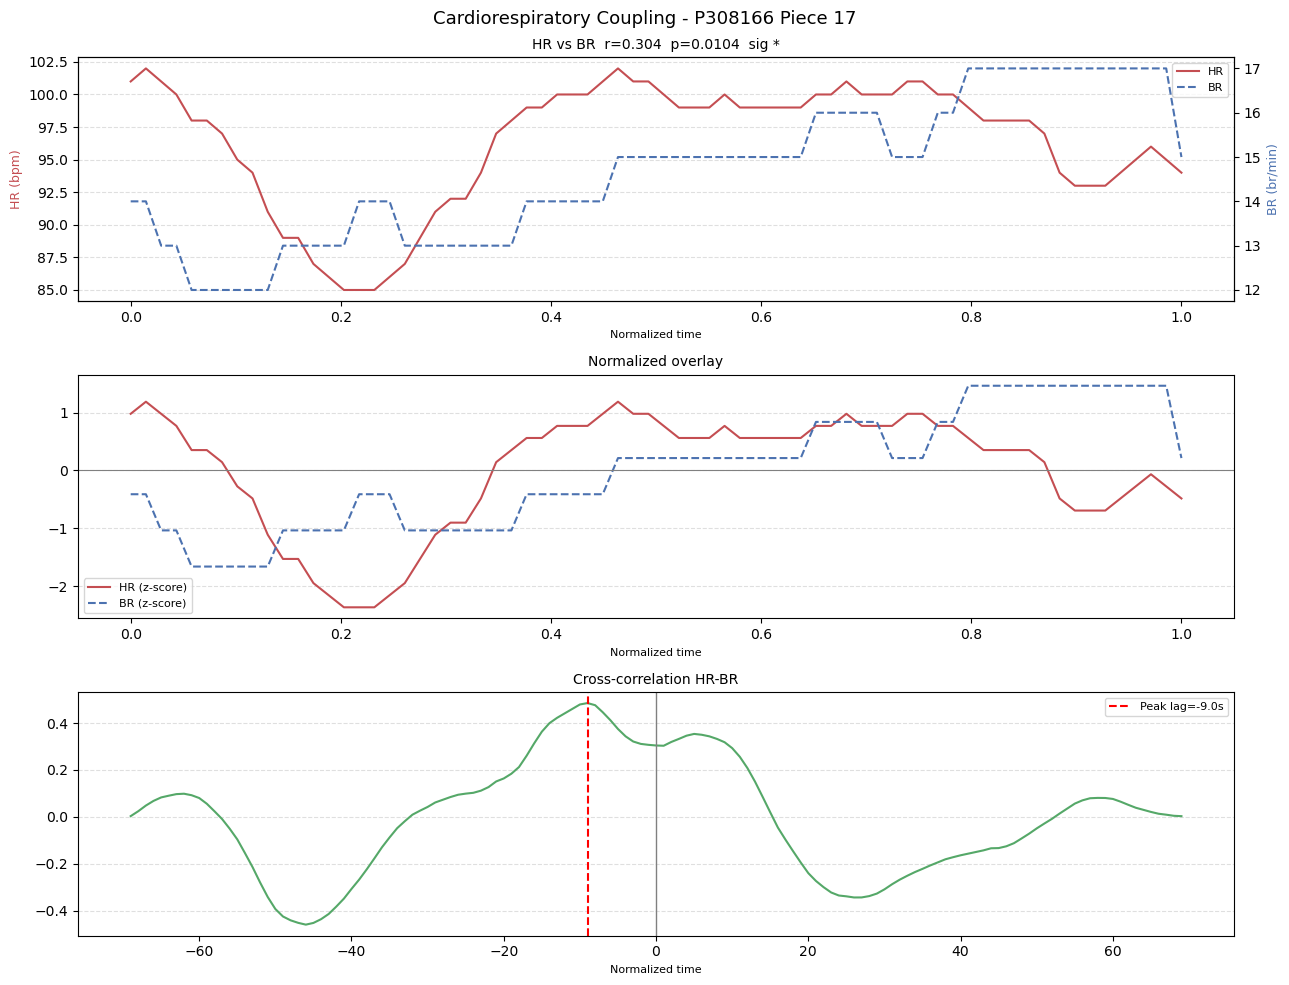

[SAVED] C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\coupling_P308166_piece17.png
[DONE] P308166 piece17  RSA=4.7915  r=0.3043  entrained=N/A


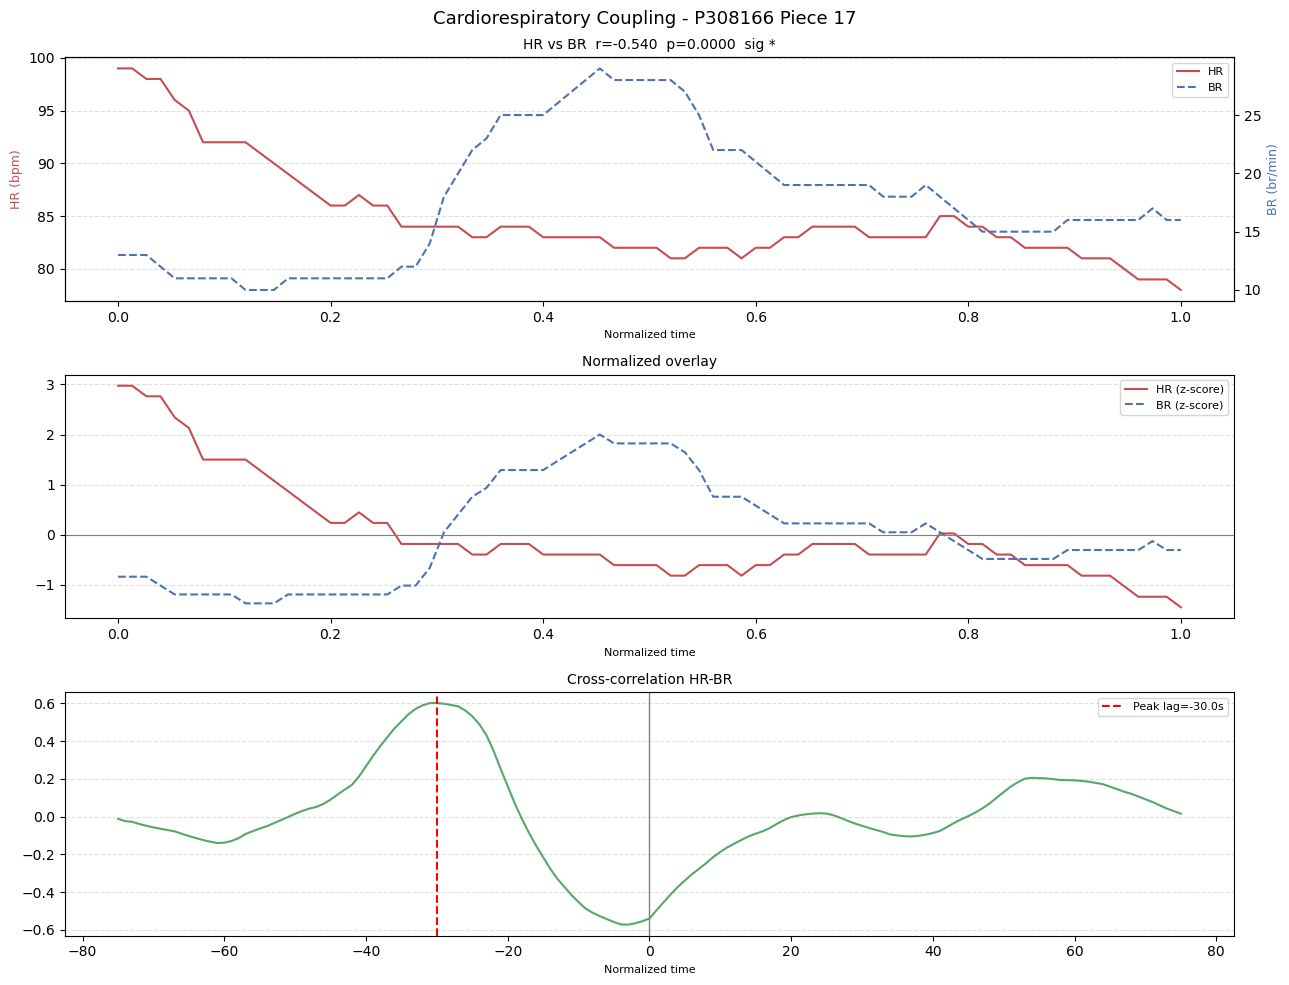

[SAVED] C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\coupling_P308166_piece17.png
[DONE] P308166 piece17  RSA=4.7527  r=-0.5397  entrained=N/A


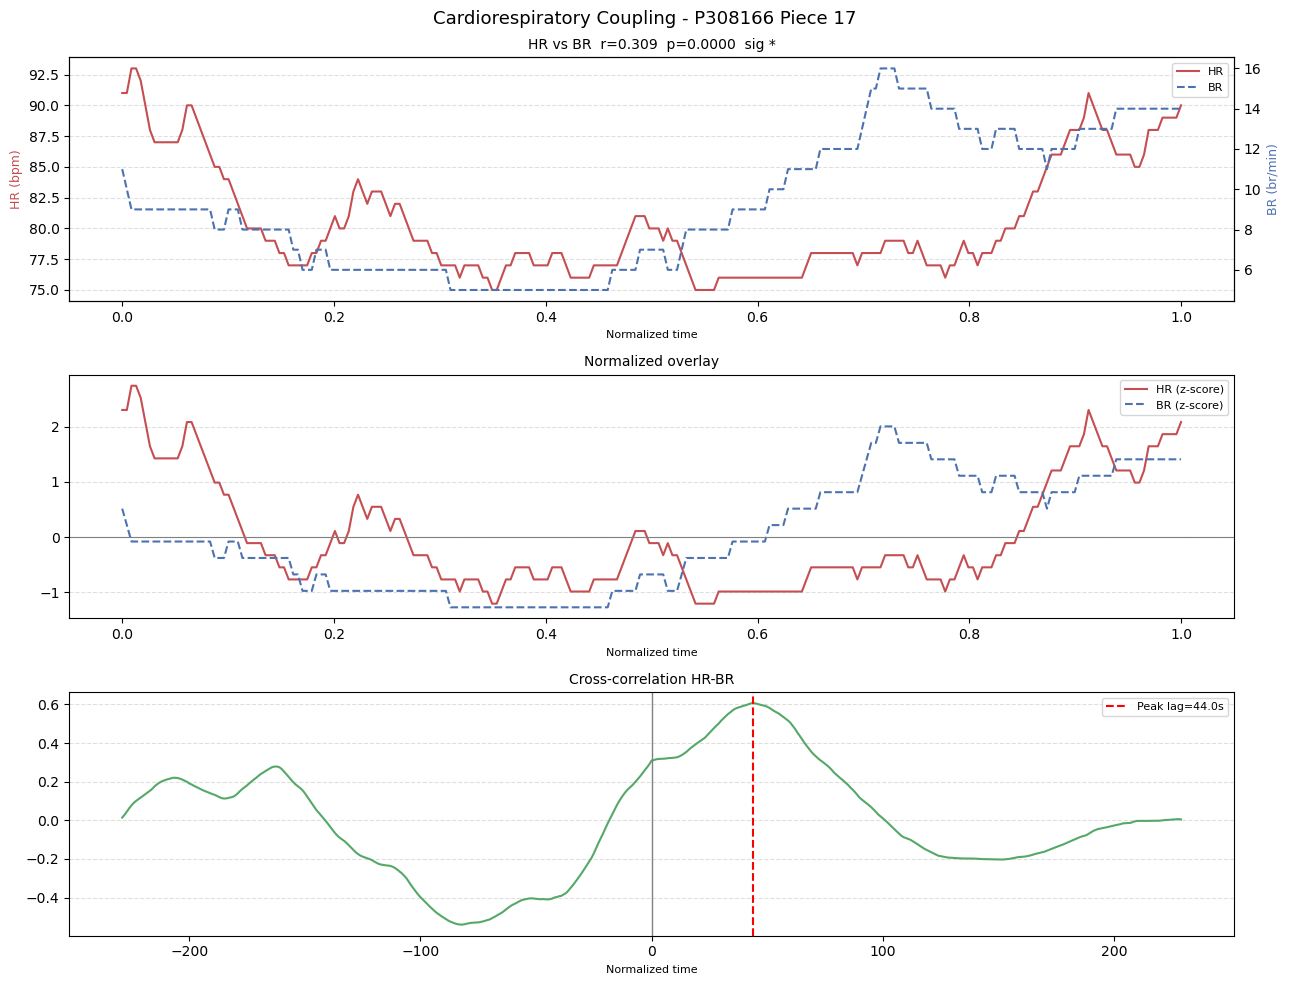

[SAVED] C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin\coupling_P308166_piece17.png
[DONE] P308166 piece17  RSA=4.5576  r=0.3091  entrained=N/A
[DONE] P308168 piece16  RSA=12.6499  r=0.0383  entrained=N/A
[DONE] P308168 piece16  RSA=14.6849  r=-0.5834  entrained=N/A
[DONE] P308168 piece16  RSA=9.7194  r=0.2906  entrained=N/A
[DONE] P308169 piece16  RSA=8.1946  r=0.677  entrained=N/A
[DONE] P308169 piece16  RSA=12.5501  r=0.9134  entrained=N/A
[DONE] P308169 piece17  RSA=7.323  r=0.1075  entrained=N/A
[DONE] P308232 piece17  RSA=5.6828  r=0.1296  entrained=N/A
[DONE] P308232 piece17  RSA=4.1581  r=0.0802  entrained=N/A
[DONE] P308232 piece17  RSA=3.4429  r=0.7932  entrained=N/A
[DONE] P308233 piece17  RSA=6.2424  r=-0.4317  entrained=N/A
[DONE] P308233 piece16  RSA=7.0506  r=0.6634  entrained=N/A
[DONE] P308233 piece16  RSA=8.1498  r=0.597  entrained=N/A
[DONE] P308234 piece17  RSA=3.9514  r=-0.7383  entrained=N/A
[DONE] P308234 piece17  RSA=8.3266  r=-0.0782  entrained=N/A
[DONE] P3

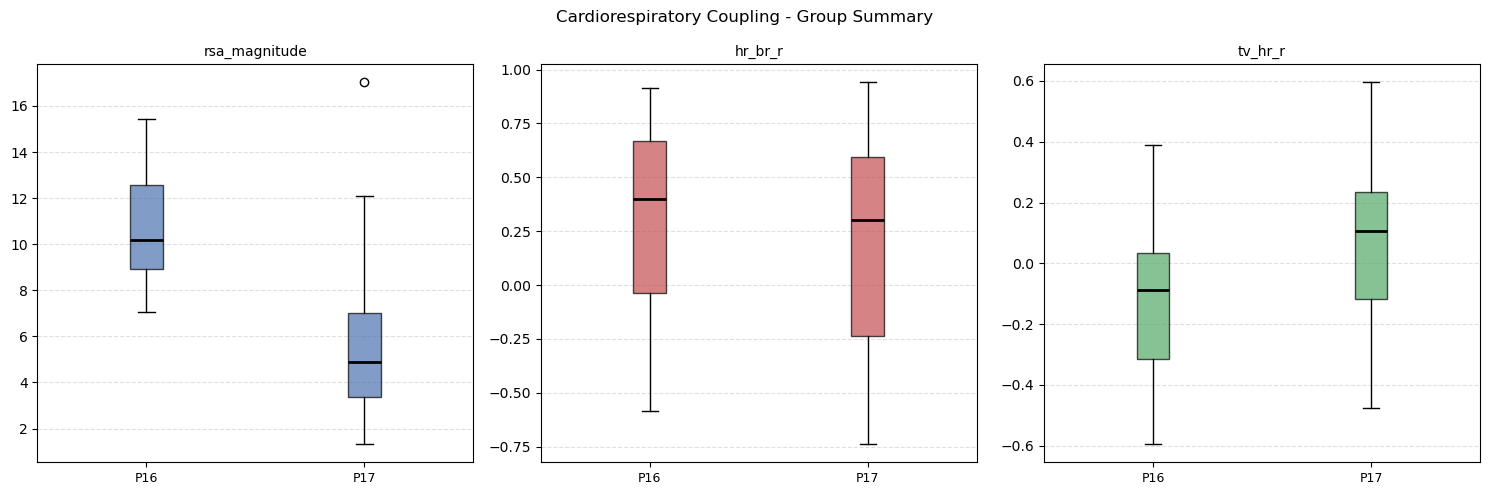

[SAVED] cardiorespiratory_coupling.csv


In [ ]:
import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')


def load_wav(folder, fname, lo, hi):
    sys.path.insert(0, folder)
    import load_hx_data
    load_hx_data.set_device_model('hx')
    path = os.path.join(folder, fname)
    if not os.path.exists(path):
        return None, None
    df   = pd.DataFrame(load_hx_data.load_wave(path), columns=['time','val'])
    t, v = df['time'].to_numpy(), df['val'].to_numpy()
    if v.mean() > 1000: v = v / 1000
    mask = (v >= lo) & (v <= hi)
    return t[mask], v[mask]


def to_common_grid(t1, v1, t2, v2):
    t_s, t_e = max(t1[0], t2[0]), min(t1[-1], t2[-1])
    if t_e <= t_s: return None, None, None
    tc = np.linspace(t_s, t_e, min(len(v1), len(v2)))
    v1i = interp1d(t1, v1, bounds_error=False, fill_value='extrapolate')(tc)
    v2i = interp1d(t2, v2, bounds_error=False, fill_value='extrapolate')(tc)
    return tc, v1i, v2i


def analyze_coupling(folder, tempo=None):
    hr_t, hr_v = load_wav(folder, 'heart_rate.wav', 30, 220)
    br_t, br_v = load_wav(folder, 'breathing_rate.wav', 2, 60)
    tv_t, tv_v = load_wav(folder, 'tidal_volume.wav', 0, 5000)

    if hr_v is None or br_v is None:
        return None, None

    tc, hr_i, br_i = to_common_grid(hr_t, hr_v, br_t, br_v)
    if tc is None: return None, None

    r_hr_br, p_hr_br = stats.pearsonr(hr_i, br_i)
    cc   = np.correlate(hr_i - hr_i.mean(), br_i - br_i.mean(), mode='full')
    cc  /= len(hr_i) * hr_i.std() * br_i.std()
    lags = np.arange(-len(hr_i)+1, len(hr_i))
    lag  = lags[np.argmax(np.abs(cc))]

    res = {
        'rsa_magnitude': round(float(hr_i.std()), 4),
        'hr_br_r'      : round(float(r_hr_br), 4),
        'hr_br_p'      : round(float(p_hr_br), 4),
        'peak_lag_s'   : round(float(lag), 2),
    }

    if tempo:
        dist = abs(br_v.mean() - tempo/4)
        res.update({
            'mean_br'          : round(float(br_v.mean()), 3),
            'entrainment_index': round(1/(1+dist), 4),
            'entrained'        : dist < 2.0,
        })

    if tv_v is not None:
        _, tv_i, hr_i2 = to_common_grid(tv_t, tv_v, hr_t, hr_v)
        if tv_i is not None:
            r, p = stats.pearsonr(tv_i, hr_i2)
            res.update({'tv_hr_r': round(float(r),4), 'tv_hr_p': round(float(p),4)})

    rsa_data = {'tc': tc, 'hr': hr_i, 'br': br_i, 'cc': cc, 'lags': lags, 'lag': lag,
                'r': r_hr_br, 'p': p_hr_br}
    return res, rsa_data


def plot_coupling(d, pid, piece, base_folder):
    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    fig.suptitle(f'Cardiorespiratory Coupling - P{pid} Piece {piece}', fontsize=13)
    tn = (d['tc'] - d['tc'][0]) / (d['tc'][-1] - d['tc'][0])

    ax2 = axes[0].twinx()
    axes[0].plot(tn, d['hr'], color='#C44E52', linewidth=1.5, label='HR')
    ax2.plot(tn, d['br'], color='#4C72B0', linewidth=1.5, linestyle='--', label='BR')
    axes[0].set_ylabel('HR (bpm)', color='#C44E52', fontsize=9)
    ax2.set_ylabel('BR (br/min)', color='#4C72B0', fontsize=9)
    axes[0].set_title(f'HR vs BR  r={d["r"]:.3f}  p={d["p"]:.4f}  '
                       f'{"sig *" if d["p"]<0.05 else "not sig"}', fontsize=10)
    l1, lb1 = axes[0].get_legend_handles_labels()
    l2, lb2 = ax2.get_legend_handles_labels()
    axes[0].legend(l1+l2, lb1+lb2, fontsize=8)
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    zhr = (d['hr'] - d['hr'].mean()) / d['hr'].std()
    zbr = (d['br'] - d['br'].mean()) / d['br'].std()
    axes[1].plot(tn, zhr, color='#C44E52', linewidth=1.5, label='HR (z-score)')
    axes[1].plot(tn, zbr, color='#4C72B0', linewidth=1.5, linestyle='--', label='BR (z-score)')
    axes[1].axhline(0, color='gray', linewidth=0.8)
    axes[1].set_title('Normalized overlay', fontsize=10)
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    axes[2].plot(d['lags'], d['cc'], color='#55A868', linewidth=1.5)
    axes[2].axvline(d['lag'], color='red', linestyle='--',
                    linewidth=1.5, label=f'Peak lag={d["lag"]:.1f}s')
    axes[2].axvline(0, color='gray', linewidth=1)
    axes[2].set_title('Cross-correlation HR-BR', fontsize=10)
    axes[2].set_xlabel('Lag (samples)', fontsize=9)
    axes[2].legend(fontsize=8)
    axes[2].grid(axis='y', linestyle='--', alpha=0.4)

    for ax in axes: ax.set_xlabel('Normalized time', fontsize=8)
    plt.tight_layout()
    out = os.path.join(base_folder, f'coupling_P{pid}_piece{piece}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {out}")


def run_all(base_folder, audio_tempos=None):
    results, n_plotted = [], 0

    for range_f in sorted(os.listdir(base_folder)):
        range_path = os.path.join(base_folder, range_f)
        if not os.path.isdir(range_path): continue
        for i, record_f in enumerate(sorted(os.listdir(range_path))):
            record_path = os.path.join(range_path, record_f)
            if not os.path.isdir(record_path): continue
            match = re.search(r'record_(\d+)', record_f)
            if not match: continue
            pid    = match.group(1)
            folder = os.path.join(record_path, record_f)
            if not os.path.isdir(folder): folder = record_path
            piece  = i + 1
            tempo  = audio_tempos.get(piece) if audio_tempos else None
            try:
                res, rsa = analyze_coupling(folder, tempo)
                if res is None: continue
                res.update({'participant_id': pid, 'range_folder': range_f, 'piece': piece})
                results.append(res)
                if n_plotted < 3:
                    plot_coupling(rsa, pid, piece, base_folder)
                    n_plotted += 1
                print(f"[DONE] P{pid} piece{piece}  RSA={res['rsa_magnitude']}  "
                      f"r={res['hr_br_r']}  entrained={res.get('entrained','N/A')}")
            except Exception as e:
                print(f"[ERROR] P{pid} {range_f} - {e}")

    if not results:
        print("[WARN] No results")
        return pd.DataFrame()

    df  = pd.DataFrame(results)
    cols = [c for c in ['rsa_magnitude','hr_br_r','entrainment_index','tv_hr_r'] if c in df.columns]

    print(f"\n{'='*55}\n  COUPLING SUMMARY\n{'='*55}")
    print(df.groupby('piece')[cols].mean().round(4).to_string())

    fig, axes = plt.subplots(1, len(cols), figsize=(5*len(cols), 5))
    if len(cols) == 1: axes = [axes]
    fig.suptitle('Cardiorespiratory Coupling - Group Summary', fontsize=12)
    for ax, col, color in zip(axes, cols,
                               ['#4C72B0','#C44E52','#55A868','#DD8452']):
        pieces = sorted(df['piece'].dropna().unique())
        ax.boxplot([df[df['piece']==p][col].dropna().tolist() for p in pieces],
                   patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.7),
                   medianprops=dict(color='black', linewidth=2))
        ax.set_xticklabels([f'P{p}' for p in pieces], fontsize=9)
        ax.set_title(col, fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, 'coupling_summary.png'), dpi=150)
    plt.show()

    df.to_csv(os.path.join(base_folder, 'cardiorespiratory_coupling.csv'), index=False)
    print(f"[SAVED] cardiorespiratory_coupling.csv")
    return df


if __name__ == '__main__':
    base_folder  = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'
    audio_tempos = {1: 66.3, 2: 90.0, 3: 120.0}  # update with actual tempos
    df = run_all(base_folder, audio_tempos)

[INFO] Common participants: 26


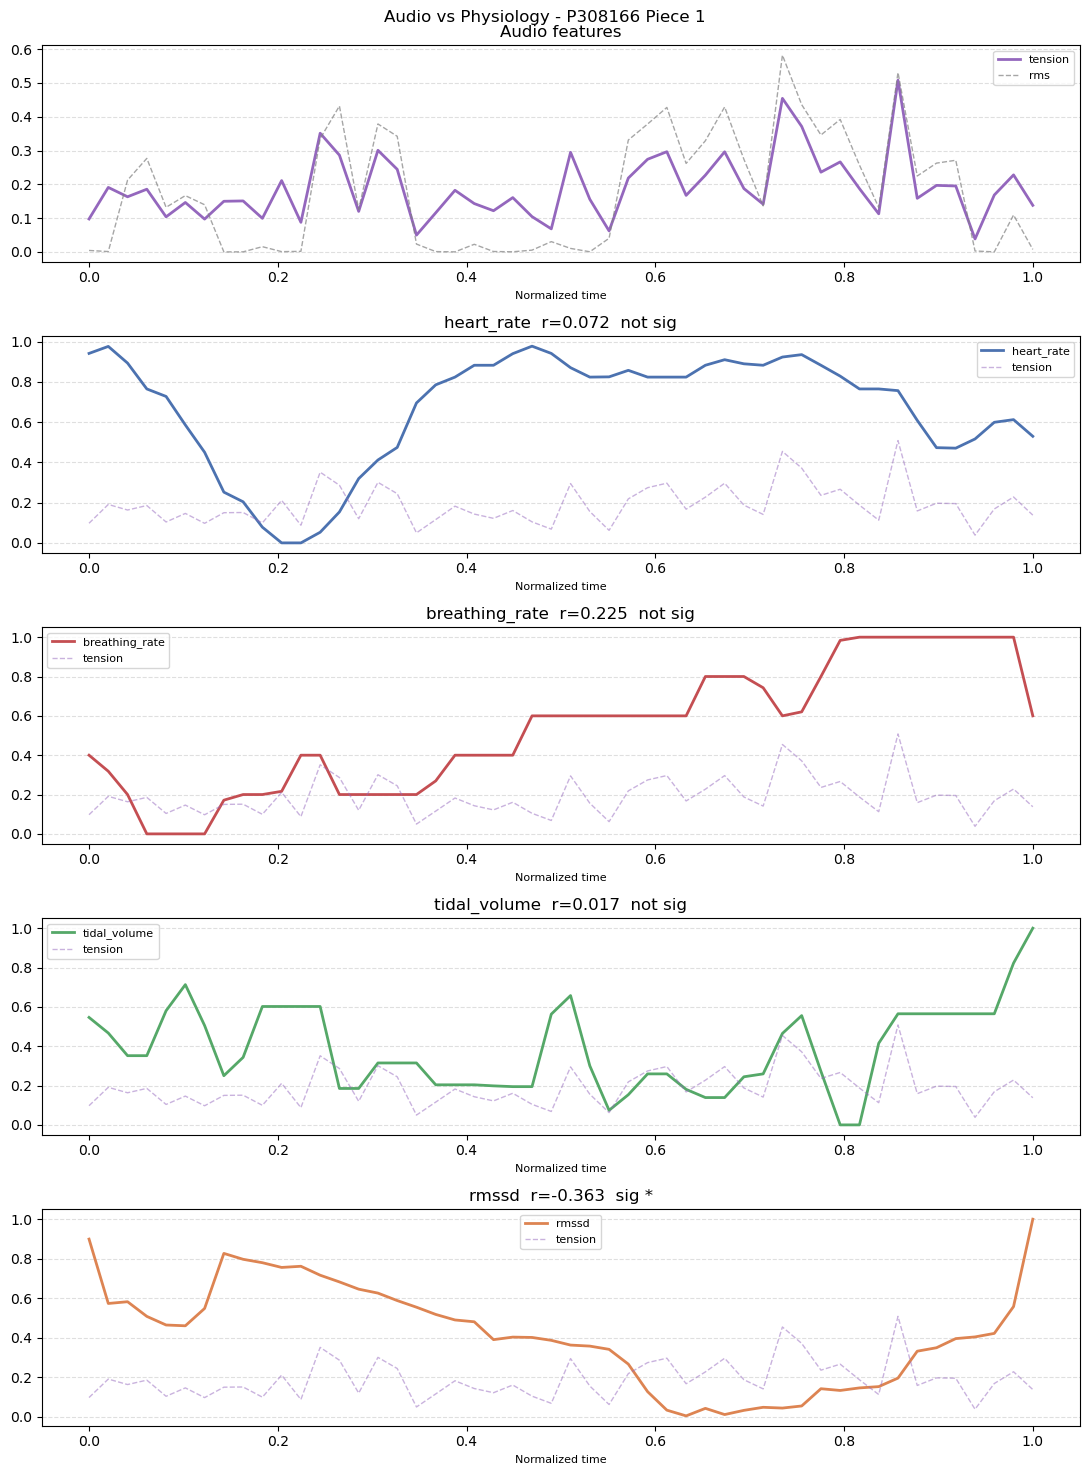

[DONE] P308166 piece1


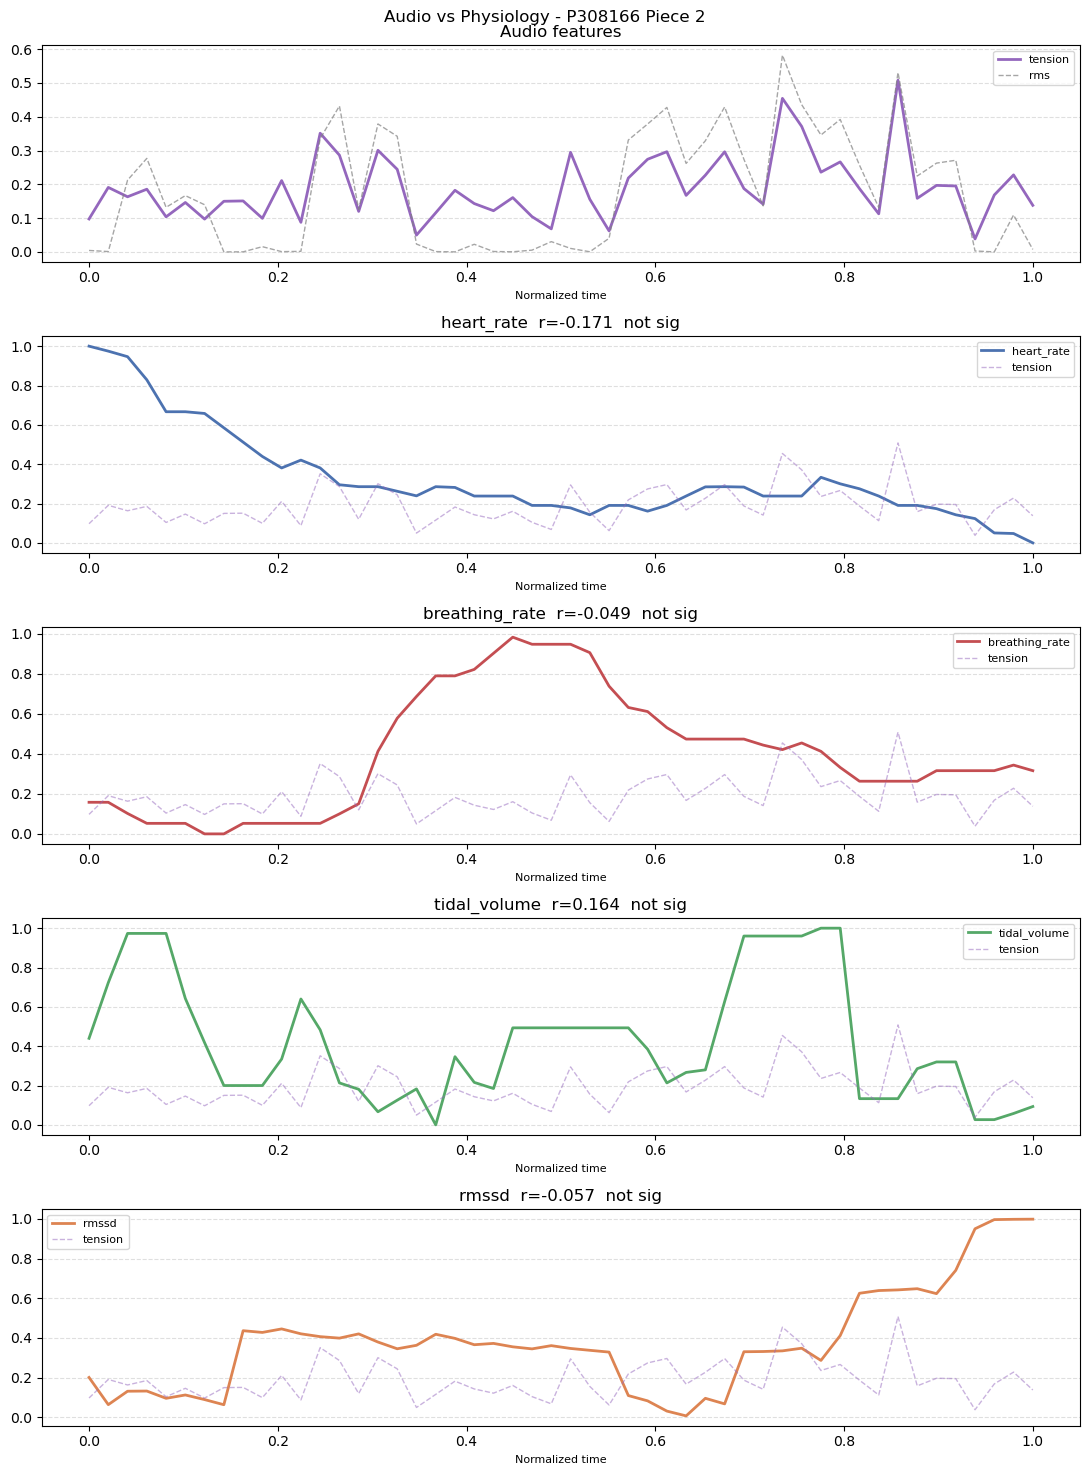

[DONE] P308166 piece2


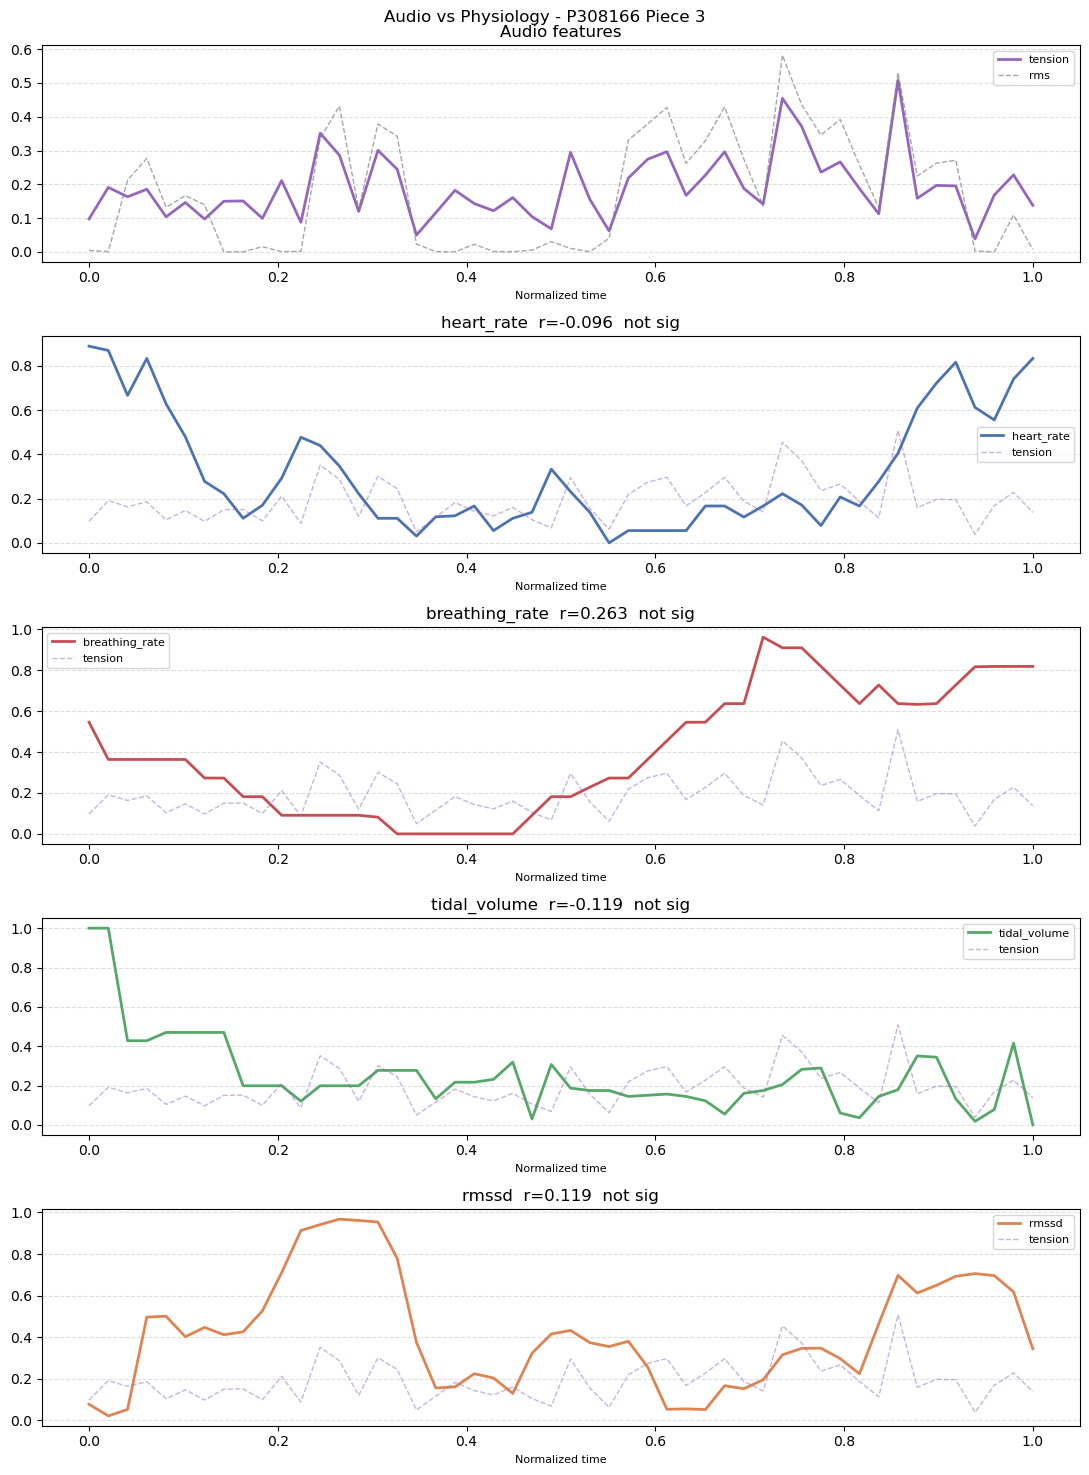

[DONE] P308166 piece3
[DONE] P308168 piece1
[DONE] P308168 piece2
[DONE] P308168 piece3
[DONE] P308169 piece1
[DONE] P308169 piece2
[DONE] P308169 piece3
[DONE] P308232 piece1
[DONE] P308232 piece2
[DONE] P308232 piece3
[DONE] P308233 piece1
[DONE] P308233 piece2
[DONE] P308233 piece3
[DONE] P308234 piece1
[DONE] P308234 piece2
[DONE] P308234 piece3
[DONE] P308235 piece1
[DONE] P308235 piece2
[DONE] P308308 piece1
[DONE] P308308 piece2
[DONE] P308308 piece3
[DONE] P308310 piece1
[DONE] P308310 piece2
[DONE] P308310 piece3
[DONE] P308711 piece1
[DONE] P308711 piece2
[DONE] P308711 piece3
[DONE] P308713 piece1
[DONE] P308713 piece2
[DONE] P308713 piece3
[DONE] P308715 piece1
[DONE] P308715 piece2
[DONE] P308715 piece3
[DONE] P308716 piece1
[DONE] P308716 piece2
[DONE] P308716 piece3
[DONE] P308717 piece1
[DONE] P308717 piece2
[DONE] P308717 piece3
[DONE] P308721 piece1
[DONE] P308721 piece2
[DONE] P308721 piece3
[DONE] P308754 piece1
[DONE] P308754 piece2
[DONE] P308754 piece3
[DONE] P30

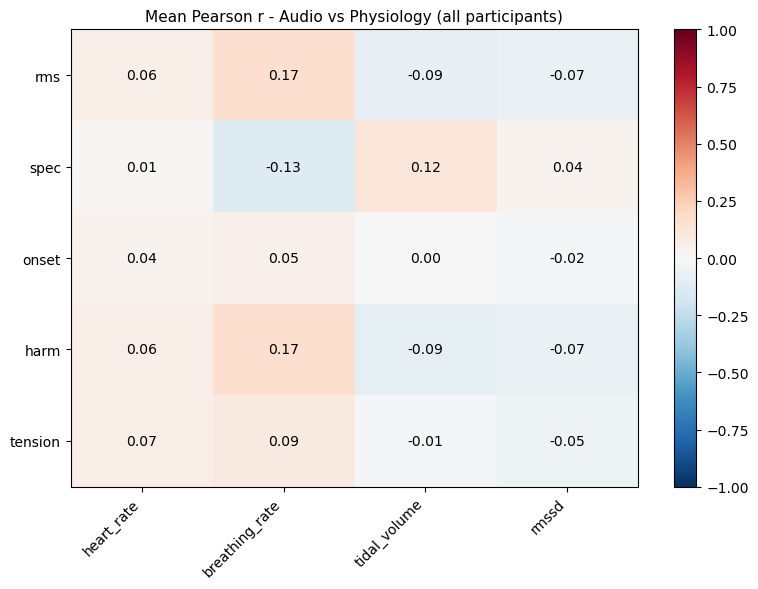

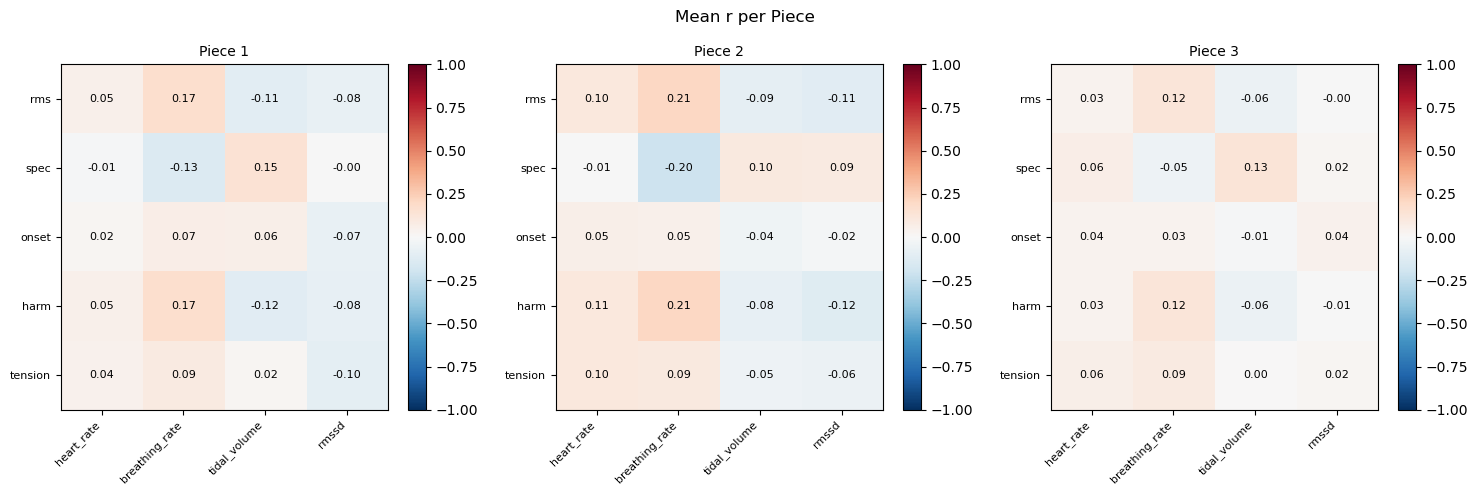


[SAVED] audio_physio_timeseries_corr.csv, audio_physio_summary.csv


In [ ]:
import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from scipy import stats
from scipy.interpolate import interp1d
from pydub import AudioSegment
import warnings
warnings.filterwarnings('ignore')


def norm(a):
    mn, mx = a.min(), a.max()
    return (a - mn) / (mx - mn) if mx != mn else np.zeros_like(a)


def norm_resample(arr, n=50):
    t, tc = np.linspace(0, 1, len(arr)), np.linspace(0, 1, n)
    return interp1d(t, norm(arr), bounds_error=False, fill_value='extrapolate')(tc)


def load_audio(path, sr=22050):
    audio = AudioSegment.from_file(path, format='mp3').set_channels(1).set_frame_rate(sr)
    y = np.array(audio.get_array_of_samples()).astype(np.float32)
    return y / np.iinfo(np.int16).max, sr


def extract_audio_features(audio_path, n=50):
    y, sr   = load_audio(audio_path)
    tempo,_ = librosa.beat.beat_track(y=y, sr=sr)
    rms     = librosa.feature.rms(y=y)[0]
    spec    = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    onset   = librosa.onset.onset_strength(y=y, sr=sr)
    harm    = librosa.feature.rms(y=librosa.effects.hpss(y)[0])[0]
    n_pts   = min(len(rms), len(spec), len(onset), len(harm))
    tension = norm(rms[:n_pts])*0.4 + norm(spec[:n_pts])*0.3 + norm(onset[:n_pts])*0.3

    summary = {
        'duration_s' : round(len(y)/sr, 1),
        'tempo_bpm'  : round(float(tempo), 1),
        'mean_rms'   : round(float(rms.mean()), 4),
        'mean_tension': round(float(tension.mean()), 4),
        'onset_rate' : round(len(librosa.onset.onset_detect(y=y, sr=sr))/(len(y)/sr), 3),
    }
    ts = {f: norm_resample(arr[:n_pts], n) for f, arr in
          [('rms',rms),('spec',spec),('onset',onset),('harm',harm)]}
    ts['tension'] = norm_resample(tension, n)
    return summary, ts


def load_wav(folder, fname, lo, hi, n=50, as_ts=True):
    sys.path.insert(0, folder)
    import load_hx_data
    load_hx_data.set_device_model('hx')
    path = os.path.join(folder, fname)
    if not os.path.exists(path):
        return None
    vals = pd.DataFrame(load_hx_data.load_wave(path), columns=['t','v'])['v'].to_numpy()
    if vals.mean() > 1000: vals = vals / 1000
    mask = (vals >= lo) & (vals <= hi)
    if mask.sum() < 3:
        return None
    return norm_resample(vals[mask], n) if as_ts else float(vals[mask].mean())


def load_rmssd_ts(folder, n=50, window=30):
    rr_csv = os.path.join(folder, 'RR_interval.csv')
    if not os.path.exists(rr_csv):
        return None
    df = pd.read_csv(rr_csv)
    t, rr = df.iloc[:,0].to_numpy(), df.iloc[:,1].to_numpy()
    if rr.mean() > 10: rr = rr / 1000
    vals = [np.sqrt(np.mean(np.diff(rr[(t>=ti-window)&(t<=ti)])**2))*1000
            for ti in t if len(rr[(t>=ti-window)&(t<=ti)]) >= 5]
    return norm_resample(np.array(vals), n) if len(vals) >= 3 else None


def load_phys(folder, n=50):
    ts = {'heart_rate': load_wav(folder,'heart_rate.wav',30,220,n),
          'breathing_rate': load_wav(folder,'breathing_rate.wav',2,60,n),
          'tidal_volume': load_wav(folder,'tidal_volume.wav',0,5000,n),
          'rmssd': load_rmssd_ts(folder, n)}
    means = {'mean_hr': load_wav(folder,'heart_rate.wav',30,220,as_ts=False),
             'mean_br': load_wav(folder,'breathing_rate.wav',2,60,as_ts=False),
             'mean_tv': load_wav(folder,'tidal_volume.wav',0,5000,as_ts=False)}
    return {k:v for k,v in ts.items() if v is not None}, means


def build_maps(audio_folder, base_folder):
    audio_map = {}
    for f in sorted(os.listdir(audio_folder)):
        m = re.search(r'P(\d+)_video(\d+)', f)
        if m:
            audio_map.setdefault(m.group(1), {})[int(m.group(2))] = os.path.join(audio_folder, f)

    hx_map = {}
    for rf in sorted(os.listdir(base_folder)):
        rp = os.path.join(base_folder, rf)
        if not os.path.isdir(rp): continue
        for recf in sorted(os.listdir(rp)):
            recp = os.path.join(rp, recf)
            if not os.path.isdir(recp): continue
            m = re.search(r'record_(\d+)', recf)
            if not m: continue
            folder = os.path.join(recp, recf)
            if not os.path.isdir(folder): folder = recp
            hx_map.setdefault(m.group(1), []).append((rf, folder))
    for pid in hx_map: hx_map[pid] = sorted(hx_map[pid], key=lambda x: x[0])

    a_ids, h_ids = sorted(audio_map, key=int), sorted(hx_map, key=int)
    pid_map = dict(zip(a_ids, h_ids))
    audio_map = {pid_map[a]: p for a, p in audio_map.items() if a in pid_map}
    common = sorted(set(audio_map) & set(hx_map), key=int)
    print(f"[INFO] Common participants: {len(common)}")
    return audio_map, hx_map, common


def run_correlation(audio_folder, base_folder, n=50, max_plots=3):
    audio_map, hx_map, common = build_maps(audio_folder, base_folder)
    audio_f = ['rms','spec','onset','harm','tension']
    phys_f  = ['heart_rate','breathing_rate','tidal_volume','rmssd']
    ts_corr, sum_rows, n_plotted = [], [], 0

    for pid in common:
        for piece, (rf, folder) in enumerate(hx_map[pid][:3], 1):
            ap = audio_map.get(pid, {}).get(piece)
            if ap is None: continue
            try:
                a_sum, a_ts = extract_audio_features(ap, n)
                p_ts, p_means = load_phys(folder, n)

                for af in audio_f:
                    for pf in phys_f:
                        if pf not in p_ts: continue
                        r, p = stats.pearsonr(a_ts[af], p_ts[pf])
                        ts_corr.append({'participant_id':pid,'piece':piece,
                                        'audio_feature':af,'phys_feature':pf,
                                        'r':round(r,4),'p':round(p,4),'significant':p<0.05})

                row = {'participant_id':pid,'piece':piece,'range_folder':rf, **a_sum, **p_means}
                sum_rows.append(row)

                if n_plotted < max_plots:
                    plot_overlay(a_ts, p_ts, pid, piece, base_folder)
                    n_plotted += 1
                print(f"[DONE] P{pid} piece{piece}")
            except Exception as e:
                print(f"[ERROR] P{pid} piece{piece} - {e}")

    ts_df, sum_df = pd.DataFrame(ts_corr), pd.DataFrame(sum_rows)
    if ts_df.empty:
        print("[WARN] No correlations computed")
        return ts_df, sum_df

    ts_df.to_csv(os.path.join(base_folder,'audio_physio_timeseries_corr.csv'), index=False)
    sum_df.to_csv(os.path.join(base_folder,'audio_physio_summary.csv'), index=False)

    # Level 1 - summary correlations
    print(f"\n{'='*55}\n  LEVEL 1 - SUMMARY CORRELATIONS\n{'='*55}")
    print(f"  {'Audio':<15} {'Physio':<10} {'r':>8} {'p':>8} {'Sig':>6}")
    for af in ['tempo_bpm','mean_rms','mean_tension','onset_rate']:
        for pf in ['mean_hr','mean_br','mean_tv']:
            v = sum_df[[af,pf]].dropna()
            if len(v) < 3: continue
            r, p = stats.pearsonr(v[af], v[pf])
            print(f"  {af:<15} {pf:<10} {r:>8.4f} {p:>8.4f} {'YES *' if p<0.05 else 'no':>6}")

    # Level 2 - time series correlations
    print(f"\n{'='*55}\n  LEVEL 2 - TIME SERIES CORRELATIONS\n{'='*55}")
    grp = ts_df.groupby(['audio_feature','phys_feature']).agg(
          mean_r=('r','mean'), std_r=('r','std'),
          pct_sig=('significant','mean'), n=('r','count')).reset_index()
    grp = grp.sort_values('mean_r', key=abs, ascending=False)
    print(f"  {'Audio':<10} {'Physio':<15} {'Mean r':>8} {'Std r':>8} {'%Sig':>7} {'n':>4}")
    for _, row in grp.iterrows():
        sig = 'YES *' if row['pct_sig']>0.5 else 'no'
        print(f"  {row['audio_feature']:<10} {row['phys_feature']:<15} "
              f"{row['mean_r']:>8.4f} {row['std_r']:>8.4f} {row['pct_sig']*100:>6.1f}% "
              f"{int(row['n']):>4}  {sig}")

    plot_heatmap(grp, audio_f, phys_f, base_folder)
    plot_per_piece(ts_df, audio_f, phys_f, base_folder)
    print(f"\n[SAVED] audio_physio_timeseries_corr.csv, audio_physio_summary.csv")
    return ts_df, sum_df


def plot_overlay(a_ts, p_ts, pid, piece, base_folder):
    t = np.linspace(0, 1, len(a_ts['tension']))
    fig, axes = plt.subplots(len(p_ts)+1, 1, figsize=(11, 3*(len(p_ts)+1)))
    fig.suptitle(f'Audio vs Physiology - P{pid} Piece {piece}', fontsize=12)

    axes[0].plot(t, a_ts['tension'], color='#9467BD', linewidth=2, label='tension')
    axes[0].plot(t, a_ts['rms'], color='gray', linewidth=1, linestyle='--', alpha=0.7, label='rms')
    axes[0].set_title('Audio features')
    axes[0].legend(fontsize=8)

    for ax, (pf, pv), c in zip(axes[1:], p_ts.items(), ['#4C72B0','#C44E52','#55A868','#DD8452']):
        r, p = stats.pearsonr(a_ts['tension'], pv)
        ax.plot(t, pv, color=c, linewidth=2, label=pf)
        ax.plot(t, a_ts['tension'], color='#9467BD', linewidth=1, linestyle='--', alpha=0.5, label='tension')
        ax.set_title(f'{pf}  r={r:.3f}  {"sig *" if p<0.05 else "not sig"}')
        ax.legend(fontsize=8)

    for ax in axes:
        ax.set_xlabel('Normalized time', fontsize=8)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, f'overlay_P{pid}_piece{piece}.png'), dpi=150)
    plt.show()


def plot_heatmap(grp, audio_f, phys_f, base_folder):
    pivot = grp.pivot(index='audio_feature', columns='phys_feature', values='mean_r')
    pivot = pivot.reindex(index=audio_f, columns=phys_f)
    fig, ax = plt.subplots(figsize=(8,6))
    im = ax.imshow(pivot.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(pivot.columns))); ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(pivot.index, fontsize=10)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i,j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10,
                        color='white' if abs(val)>0.5 else 'black')
    plt.colorbar(im, ax=ax)
    ax.set_title('Mean Pearson r - Audio vs Physiology (all participants)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, 'audio_physio_heatmap.png'), dpi=150)
    plt.show()


def plot_per_piece(ts_df, audio_f, phys_f, base_folder):
    pieces = sorted(ts_df['piece'].unique())
    fig, axes = plt.subplots(1, len(pieces), figsize=(5*len(pieces), 5))
    if len(pieces) == 1: axes = [axes]
    fig.suptitle('Mean r per Piece', fontsize=12)
    for ax, piece in zip(axes, pieces):
        pivot = ts_df[ts_df['piece']==piece].groupby(
                ['audio_feature','phys_feature'])['r'].mean().unstack()
        pivot = pivot.reindex(index=audio_f, columns=phys_f)
        im = ax.imshow(pivot.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        ax.set_xticks(range(len(pivot.columns))); ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(pivot.index, fontsize=8)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i,j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
        ax.set_title(f'Piece {piece}', fontsize=10)
        plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, 'audio_physio_per_piece.png'), dpi=150)
    plt.show()


if __name__ == '__main__':
    audio_folder = r'C:\Users\manognas\Downloads\2inspire_audio\audio'
    base_folder  = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'
    ts_df, sum_df = run_correlation(audio_folder, base_folder, n=50, max_plots=3)

[INFO] Common participants: 26
[DONE] P308166 piece1  key=B major  entropy=1.84  stability=0.19
[DONE] P308166 piece2  key=B major  entropy=1.84  stability=0.19
[DONE] P308166 piece3  key=B major  entropy=1.84  stability=0.19
[DONE] P308168 piece1  key=G minor  entropy=1.62  stability=0.19
[DONE] P308168 piece2  key=G minor  entropy=1.70  stability=0.22
[DONE] P308168 piece3  key=E minor  entropy=1.98  stability=0.34
[DONE] P308169 piece1  key=G minor  entropy=1.52  stability=0.17
[DONE] P308169 piece2  key=D minor  entropy=1.73  stability=0.20
[DONE] P308169 piece3  key=F minor  entropy=1.95  stability=0.23
[DONE] P308232 piece1  key=G minor  entropy=1.51  stability=0.19
[DONE] P308232 piece2  key=G minor  entropy=1.61  stability=0.25
[DONE] P308232 piece3  key=A# minor  entropy=1.84  stability=0.28
[DONE] P308233 piece1  key=G minor  entropy=1.83  stability=0.12
[DONE] P308233 piece2  key=G minor  entropy=1.68  stability=0.21
[DONE] P308233 piece3  key=A major  entropy=1.77  stabilit

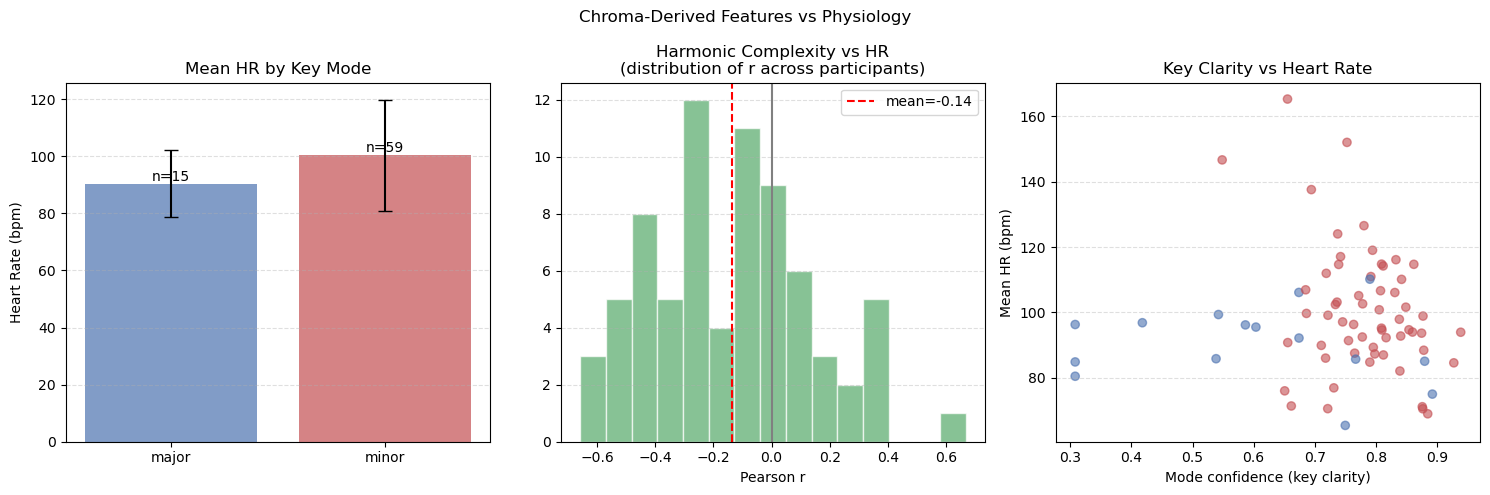

In [ ]:
import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from scipy import stats
from scipy.interpolate import interp1d
from pydub import AudioSegment
import warnings
warnings.filterwarnings('ignore')

NOTE_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

# Krumhansl-Schmuckler key profiles
MAJOR_PROFILE = np.array([6.35,2.23,3.48,2.33,4.38,4.09,2.52,5.19,2.39,3.66,2.29,2.88])
MINOR_PROFILE = np.array([6.33,2.68,3.52,5.38,2.60,3.53,2.54,4.75,3.98,2.69,3.34,3.17])


def norm(a):
    mn, mx = a.min(), a.max()
    return (a - mn) / (mx - mn) if mx != mn else np.zeros_like(a)


def norm_resample(arr, n=50):
    t, tc = np.linspace(0, 1, len(arr)), np.linspace(0, 1, n)
    return interp1d(t, norm(arr), bounds_error=False, fill_value='extrapolate')(tc)


def load_audio(path, sr=22050):
    audio = AudioSegment.from_file(path, format='mp3').set_channels(1).set_frame_rate(sr)
    y = np.array(audio.get_array_of_samples()).astype(np.float32)
    return y / np.iinfo(np.int16).max, sr


def classify_key_mode(chroma_vec):
    """Estimate major/minor key from a chroma vector using KS profiles."""
    major_corrs = [np.corrcoef(np.roll(MAJOR_PROFILE, i), chroma_vec)[0,1] for i in range(12)]
    minor_corrs = [np.corrcoef(np.roll(MINOR_PROFILE, i), chroma_vec)[0,1] for i in range(12)]
    best_major, best_minor = max(major_corrs), max(minor_corrs)
    if best_major > best_minor:
        return NOTE_NAMES[int(np.argmax(major_corrs))], 'major', best_major
    return NOTE_NAMES[int(np.argmax(minor_corrs))], 'minor', best_minor


def extract_chroma_features(audio_path, n=50):
    """
    Extract chroma-based features:
    - dominant note & major/minor mode (whole piece)
    - harmonic complexity over time (entropy of chroma distribution)
    - key stability over time (correlation of chroma to overall profile)
    - mode confidence (how clearly major or minor)
    """
    y, sr  = load_audio(audio_path)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    # Whole-piece key/mode
    chroma_mean = chroma.mean(axis=1)
    key, mode, mode_conf = classify_key_mode(chroma_mean)

    # Harmonic complexity over time = entropy of chroma distribution per frame
    chroma_norm = chroma / (chroma.sum(axis=0, keepdims=True) + 1e-9)
    entropy     = -np.sum(chroma_norm * np.log(chroma_norm + 1e-9), axis=0)

    # Key stability over time = correlation of each frame's chroma to overall mean chroma
    stability = np.array([
        np.corrcoef(chroma[:, i], chroma_mean)[0, 1] for i in range(chroma.shape[1])
    ])
    stability = np.nan_to_num(stability)

    summary = {
        'dominant_note' : key,
        'mode'          : mode,
        'mode_confidence': round(float(mode_conf), 4),
        'mean_entropy'  : round(float(entropy.mean()), 4),
        'mean_stability': round(float(stability.mean()), 4),
    }
    ts = {
        'entropy'  : norm_resample(entropy, n),
        'stability': norm_resample(stability, n),
    }
    return summary, ts


def load_wav(folder, fname, lo, hi, n=50, as_ts=True):
    sys.path.insert(0, folder)
    import load_hx_data
    load_hx_data.set_device_model('hx')
    path = os.path.join(folder, fname)
    if not os.path.exists(path):
        return None
    vals = pd.DataFrame(load_hx_data.load_wave(path), columns=['t','v'])['v'].to_numpy()
    if vals.mean() > 1000: vals = vals / 1000
    mask = (vals >= lo) & (vals <= hi)
    if mask.sum() < 3:
        return None
    return norm_resample(vals[mask], n) if as_ts else float(vals[mask].mean())


def load_rmssd_ts(folder, n=50, window=30):
    rr_csv = os.path.join(folder, 'RR_interval.csv')
    if not os.path.exists(rr_csv):
        return None
    df = pd.read_csv(rr_csv)
    t, rr = df.iloc[:,0].to_numpy(), df.iloc[:,1].to_numpy()
    if rr.mean() > 10: rr = rr / 1000
    vals = [np.sqrt(np.mean(np.diff(rr[(t>=ti-window)&(t<=ti)])**2))*1000
            for ti in t if len(rr[(t>=ti-window)&(t<=ti)]) >= 5]
    return norm_resample(np.array(vals), n) if len(vals) >= 3 else None


def load_phys(folder, n=50):
    ts = {'heart_rate': load_wav(folder,'heart_rate.wav',30,220,n),
          'breathing_rate': load_wav(folder,'breathing_rate.wav',2,60,n),
          'rmssd': load_rmssd_ts(folder, n)}
    means = {'mean_hr': load_wav(folder,'heart_rate.wav',30,220,as_ts=False),
             'mean_br': load_wav(folder,'breathing_rate.wav',2,60,as_ts=False)}
    return {k:v for k,v in ts.items() if v is not None}, means


def build_maps(audio_folder, base_folder):
    audio_map = {}
    for f in sorted(os.listdir(audio_folder)):
        m = re.search(r'P(\d+)_video(\d+)', f)
        if m:
            audio_map.setdefault(m.group(1), {})[int(m.group(2))] = os.path.join(audio_folder, f)

    hx_map = {}
    for rf in sorted(os.listdir(base_folder)):
        rp = os.path.join(base_folder, rf)
        if not os.path.isdir(rp): continue
        for recf in sorted(os.listdir(rp)):
            recp = os.path.join(rp, recf)
            if not os.path.isdir(recp): continue
            m = re.search(r'record_(\d+)', recf)
            if not m: continue
            folder = os.path.join(recp, recf)
            if not os.path.isdir(folder): folder = recp
            hx_map.setdefault(m.group(1), []).append((rf, folder))
    for pid in hx_map: hx_map[pid] = sorted(hx_map[pid], key=lambda x: x[0])

    a_ids, h_ids = sorted(audio_map, key=int), sorted(hx_map, key=int)
    pid_map = dict(zip(a_ids, h_ids))
    audio_map = {pid_map[a]: p for a, p in audio_map.items() if a in pid_map}
    common = sorted(set(audio_map) & set(hx_map), key=int)
    print(f"[INFO] Common participants: {len(common)}")
    return audio_map, hx_map, common


def run_chroma_analysis(audio_folder, base_folder, n=50):
    audio_map, hx_map, common = build_maps(audio_folder, base_folder)

    summary_rows, ts_corr = [], []

    for pid in common:
        for piece, (rf, folder) in enumerate(hx_map[pid][:3], 1):
            ap = audio_map.get(pid, {}).get(piece)
            if ap is None: continue
            try:
                c_sum, c_ts   = extract_chroma_features(ap, n)
                p_ts, p_means = load_phys(folder, n)

                row = {'participant_id':pid,'piece':piece,'range_folder':rf, **c_sum, **p_means}
                summary_rows.append(row)

                for cf in ['entropy','stability']:
                    for pf in p_ts:
                        r, p = stats.pearsonr(c_ts[cf], p_ts[pf])
                        ts_corr.append({'participant_id':pid,'piece':piece,
                                        'chroma_feature':cf,'phys_feature':pf,
                                        'r':round(r,4),'p':round(p,4),'significant':p<0.05})

                print(f"[DONE] P{pid} piece{piece}  key={c_sum['dominant_note']} {c_sum['mode']}  "
                      f"entropy={c_sum['mean_entropy']:.2f}  stability={c_sum['mean_stability']:.2f}")
            except Exception as e:
                print(f"[ERROR] P{pid} piece{piece} - {e}")

    sum_df = pd.DataFrame(summary_rows)
    ts_df  = pd.DataFrame(ts_corr)

    if sum_df.empty:
        print("[WARN] No data collected")
        return sum_df, ts_df

    sum_df.to_csv(os.path.join(base_folder, 'chroma_summary.csv'), index=False)
    ts_df.to_csv(os.path.join(base_folder, 'chroma_timeseries_corr.csv'), index=False)

    # --- Test 1: Major vs Minor mode vs HRV ---
    print(f"\n{'='*55}\n  MAJOR vs MINOR MODE - HRV COMPARISON\n{'='*55}")
    for pf in ['mean_hr', 'mean_br']:
        major = sum_df[sum_df['mode']=='major'][pf].dropna()
        minor = sum_df[sum_df['mode']=='minor'][pf].dropna()
        if len(major) >= 3 and len(minor) >= 3:
            stat, p = stats.mannwhitneyu(major, minor)
            print(f"  {pf}: major={major.mean():.2f} (n={len(major)})  "
                  f"minor={minor.mean():.2f} (n={len(minor)})  "
                  f"p={p:.4f}  {'sig *' if p<0.05 else 'not sig'}")

    # --- Test 2: Entropy/Stability time series vs physiology ---
    print(f"\n{'='*55}\n  CHROMA TIME SERIES vs PHYSIOLOGY\n{'='*55}")
    if not ts_df.empty:
        grp = ts_df.groupby(['chroma_feature','phys_feature']).agg(
              mean_r=('r','mean'), pct_sig=('significant','mean'), n=('r','count')
              ).reset_index().sort_values('mean_r', key=abs, ascending=False)
        print(f"  {'Chroma':<12} {'Physio':<15} {'Mean r':>8} {'%Sig':>7} {'n':>4}")
        for _, row in grp.iterrows():
            sig = 'YES *' if row['pct_sig']>0.5 else 'no'
            print(f"  {row['chroma_feature']:<12} {row['phys_feature']:<15} "
                  f"{row['mean_r']:>8.4f} {row['pct_sig']*100:>6.1f}% {int(row['n']):>4}  {sig}")

    # --- Test 3: Mode confidence vs RMSSD/pNN50 ---
    print(f"\n{'='*55}\n  KEY CLARITY (mode_confidence) vs PHYSIOLOGY\n{'='*55}")
    for pf in ['mean_hr', 'mean_br']:
        v = sum_df[['mode_confidence', pf]].dropna()
        if len(v) >= 3:
            r, p = stats.pearsonr(v['mode_confidence'], v[pf])
            print(f"  mode_confidence vs {pf}: r={r:.4f}  p={p:.4f}  "
                  f"{'sig *' if p<0.05 else 'not sig'}")

    plot_results(sum_df, ts_df, base_folder)
    return sum_df, ts_df


def plot_results(sum_df, ts_df, base_folder):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Chroma-Derived Features vs Physiology', fontsize=12)

    # Plot 1 - Mode distribution and mean HR per mode
    mode_hr = sum_df.groupby('mode')['mean_hr'].agg(['mean','std','count'])
    axes[0].bar(mode_hr.index, mode_hr['mean'], yerr=mode_hr['std'],
                color=['#4C72B0','#C44E52'], alpha=0.7, capsize=5)
    for i, (idx, row) in enumerate(mode_hr.iterrows()):
        axes[0].text(i, row['mean'], f"n={int(row['count'])}", ha='center', va='bottom')
    axes[0].set_title('Mean HR by Key Mode')
    axes[0].set_ylabel('Heart Rate (bpm)')
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    # Plot 2 - Entropy vs heart rate scatter
    if not ts_df.empty:
        ent_hr = ts_df[(ts_df['chroma_feature']=='entropy') & (ts_df['phys_feature']=='heart_rate')]
        axes[1].hist(ent_hr['r'], bins=15, color='#55A868', alpha=0.7, edgecolor='white')
        axes[1].axvline(ent_hr['r'].mean(), color='red', linestyle='--',
                        label=f"mean={ent_hr['r'].mean():.2f}")
        axes[1].axvline(0, color='gray')
        axes[1].set_title('Harmonic Complexity vs HR\n(distribution of r across participants)')
        axes[1].set_xlabel('Pearson r')
        axes[1].legend()
        axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    # Plot 3 - Mode confidence vs mean HR scatter
    axes[2].scatter(sum_df['mode_confidence'], sum_df['mean_hr'],
                    c=sum_df['mode'].map({'major':'#4C72B0','minor':'#C44E52'}), alpha=0.6)
    axes[2].set_title('Key Clarity vs Heart Rate')
    axes[2].set_xlabel('Mode confidence (key clarity)')
    axes[2].set_ylabel('Mean HR (bpm)')
    axes[2].grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, 'chroma_physiology.png'), dpi=150)
    plt.show()


if __name__ == '__main__':
    audio_folder = r'C:\Users\manognas\Downloads\2inspire_audio\audio'
    base_folder  = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'
    sum_df, ts_df = run_chroma_analysis(audio_folder, base_folder, n=50)

[INFO] Chroma rows   : 77
[INFO] TS corr rows  : 444
[INFO] HRV rows      : 75
[INFO] Merged rows   : 71

  STEP 1 - MAPPING VALIDATION
  [INVALID] P308166 - identical chroma across all pieces

  Invalid participants : 1
  Valid participants  : 25

  STEP 2 - ENTROPY ACROSS PIECES
  Kruskal-Wallis: H=35.572  p=0.0000  sig *

  Pairwise Mann-Whitney:
    Piece 1 vs Piece 2: mean=1.502 vs 1.561  p=0.0132  sig *
    Piece 1 vs Piece 3: mean=1.502 vs 1.813  p=0.0000  sig *
    Piece 2 vs Piece 3: mean=1.561 vs 1.813  p=0.0000  sig *

  STEP 3 - MAJOR vs MINOR → HRV
  RMSSD              major=147.393 (n=11)  minor=172.335 (n=57)  p=0.1720  r=-0.263  not sig
  pNN50              major=50.133 (n=11)  minor=37.009 (n=57)  p=0.0484  r=-0.380  sig *
  SD1_SD2_ratio      major=0.274 (n=11)  minor=0.245 (n=57)  p=0.3957  r=-0.164  not sig
  mean_hr            major=91.680 (n=11)  minor=100.699 (n=57)  p=0.1883  r=0.254  not sig
  mean_br            major=20.131 (n=11)  minor=21.579 (n=57)  p=0.205

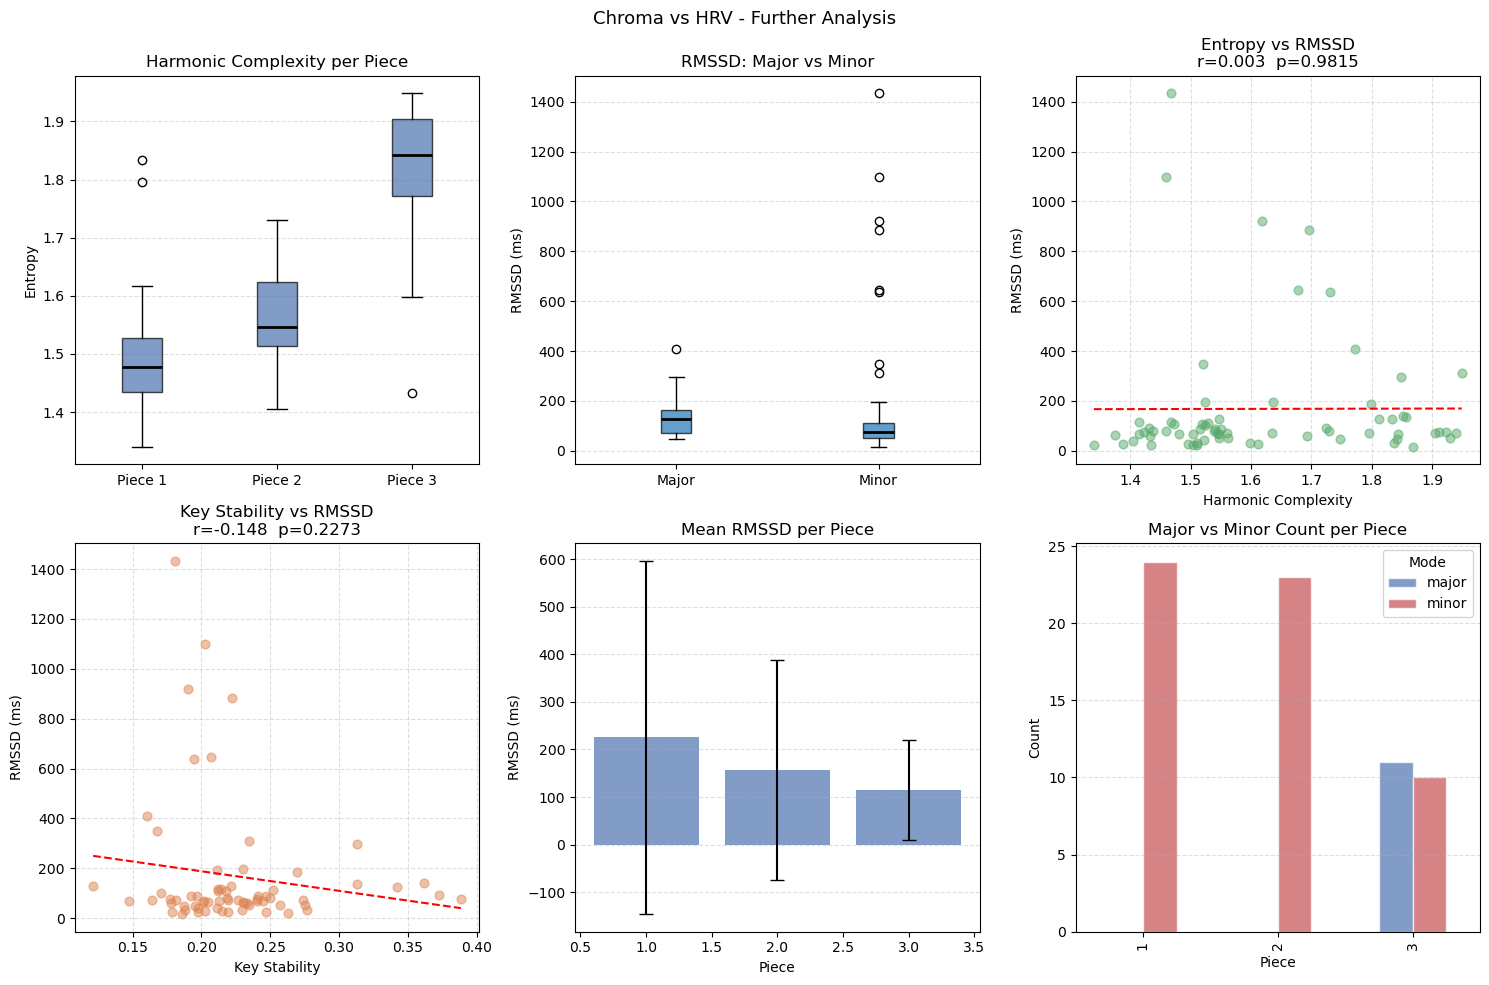

[SAVED] chroma_further_analysis.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


def load_data(base_folder):
    """Load all previously computed CSVs."""
    chroma_csv = os.path.join(base_folder, 'chroma_summary.csv')
    ts_csv     = os.path.join(base_folder, 'chroma_timeseries_corr.csv')
    hrv_csv    = os.path.join(base_folder, 'hrv_metrics_all_participants.csv')

    sum_df = pd.read_csv(chroma_csv)
    ts_df  = pd.read_csv(ts_csv)
    hrv_df = pd.read_csv(hrv_csv)

    # Assign piece number to HRV data
    hrv_df['piece'] = hrv_df.groupby('participant_id')['range_folder'].rank(
                      method='first').astype(int)

    # Merge chroma summary with HRV
    merged = pd.merge(sum_df, hrv_df[['participant_id','piece','RMSSD','pNN50','SD1_SD2_ratio']],
                      on=['participant_id','piece'], how='inner')

    print(f"[INFO] Chroma rows   : {len(sum_df)}")
    print(f"[INFO] TS corr rows  : {len(ts_df)}")
    print(f"[INFO] HRV rows      : {len(hrv_df)}")
    print(f"[INFO] Merged rows   : {len(merged)}")
    return sum_df, ts_df, hrv_df, merged


def step1_fix_mapping(sum_df):
    """
    Step 1 - Identify and remove participants with identical
    chroma values across all 3 pieces (audio mapping error).
    """
    print(f"\n{'='*55}\n  STEP 1 - MAPPING VALIDATION\n{'='*55}")

    invalid_pids = []
    for pid, grp in sum_df.groupby('participant_id'):
        if grp['mean_entropy'].nunique() == 1 and grp['mean_stability'].nunique() == 1:
            print(f"  [INVALID] P{pid} - identical chroma across all pieces")
            invalid_pids.append(pid)

    valid_df = sum_df[~sum_df['participant_id'].isin(invalid_pids)].copy()
    print(f"\n  Invalid participants : {len(invalid_pids)}")
    print(f"  Valid participants  : {valid_df['participant_id'].nunique()}")
    return valid_df, invalid_pids


def step2_entropy_across_pieces(merged):
    """
    Step 2 - Test if entropy increases significantly from Piece 1 to Piece 3.
    Uses Kruskal-Wallis + pairwise Mann-Whitney.
    """
    print(f"\n{'='*55}\n  STEP 2 - ENTROPY ACROSS PIECES\n{'='*55}")

    pieces = sorted(merged['piece'].unique())
    groups = [merged[merged['piece']==p]['mean_entropy'].dropna() for p in pieces]

    kw_stat, kw_p = stats.kruskal(*groups)
    print(f"  Kruskal-Wallis: H={kw_stat:.3f}  p={kw_p:.4f}  "
          f"{'sig *' if kw_p<0.05 else 'not sig'}")

    print(f"\n  Pairwise Mann-Whitney:")
    from itertools import combinations
    for p1, p2 in combinations(pieces, 2):
        g1 = merged[merged['piece']==p1]['mean_entropy'].dropna()
        g2 = merged[merged['piece']==p2]['mean_entropy'].dropna()
        stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f"    Piece {p1} vs Piece {p2}: "
              f"mean={g1.mean():.3f} vs {g2.mean():.3f}  "
              f"p={p:.4f}  {'sig *' if p<0.05 else 'not sig'}")


def step3_major_minor_vs_hrv(merged):
    """
    Step 3 - Compare RMSSD, pNN50, SD1/SD2 between major and minor pieces.
    """
    print(f"\n{'='*55}\n  STEP 3 - MAJOR vs MINOR → HRV\n{'='*55}")

    metrics = ['RMSSD','pNN50','SD1_SD2_ratio','mean_hr','mean_br']
    metrics = [m for m in metrics if m in merged.columns]

    for m in metrics:
        major = merged[merged['mode']=='major'][m].dropna()
        minor = merged[merged['mode']=='minor'][m].dropna()
        if len(major) < 2 or len(minor) < 2:
            continue
        stat, p = stats.mannwhitneyu(major, minor, alternative='two-sided')
        r_eff   = 1 - (2*stat)/(len(major)*len(minor))
        print(f"  {m:<18} major={major.mean():.3f} (n={len(major)})  "
              f"minor={minor.mean():.3f} (n={len(minor)})  "
              f"p={p:.4f}  r={r_eff:.3f}  {'sig *' if p<0.05 else 'not sig'}")


def step4_entropy_vs_hrv(merged):
    """
    Step 4 - Correlate harmonic complexity (entropy) with HRV metrics.
    """
    print(f"\n{'='*55}\n  STEP 4 - ENTROPY vs HRV METRICS\n{'='*55}")

    metrics = ['RMSSD','pNN50','SD1_SD2_ratio','mean_hr','mean_br']
    metrics = [m for m in metrics if m in merged.columns]

    print(f"  {'Feature':<18} {'r':>8} {'p':>8} {'Sig':>6}")
    print(f"  {'-'*42}")

    results = []
    for m in metrics:
        v = merged[['mean_entropy', m]].dropna()
        if len(v) < 3: continue
        r, p = stats.pearsonr(v['mean_entropy'], v[m])
        sig  = 'YES *' if p < 0.05 else 'no'
        print(f"  entropy vs {m:<12} {r:>8.4f} {p:>8.4f} {sig:>6}")
        results.append({'feature': m, 'r': r, 'p': p})

    return pd.DataFrame(results)


def step5_stability_vs_hrv(merged):
    """
    Step 5 - Correlate key stability with HRV metrics.
    Low stability = piece modulates a lot = more tension.
    """
    print(f"\n{'='*55}\n  STEP 5 - KEY STABILITY vs HRV METRICS\n{'='*55}")

    metrics = ['RMSSD','pNN50','SD1_SD2_ratio','mean_hr','mean_br']
    metrics = [m for m in metrics if m in merged.columns]

    print(f"  {'Feature':<18} {'r':>8} {'p':>8} {'Sig':>6}")
    print(f"  {'-'*42}")

    for m in metrics:
        v = merged[['mean_stability', m]].dropna()
        if len(v) < 3: continue
        r, p = stats.pearsonr(v['mean_stability'], v[m])
        sig  = 'YES *' if p < 0.05 else 'no'
        print(f"  stability vs {m:<12} {r:>8.4f} {p:>8.4f} {sig:>6}")


def step6_piece_hrv_change(merged):
    """
    Step 6 - Test if HRV changes from Piece 1 to Piece 3.
    Direct test of whether music progression affects autonomic state.
    """
    print(f"\n{'='*55}\n  STEP 6 - HRV CHANGE PIECE 1 vs PIECE 3\n{'='*55}")

    metrics = ['RMSSD','pNN50','SD1_SD2_ratio','mean_hr','mean_br']
    metrics = [m for m in metrics if m in merged.columns]

    for m in metrics:
        p1 = merged[merged['piece']==1][m].dropna()
        p3 = merged[merged['piece']==3][m].dropna()
        if len(p1) < 3 or len(p3) < 3: continue
        stat, p = stats.wilcoxon(p1[:min(len(p1),len(p3))],
                                  p3[:min(len(p1),len(p3))])
        direction = 'UP' if p3.mean() > p1.mean() else 'DOWN'
        print(f"  {m:<18} Piece1={p1.mean():.3f}  Piece3={p3.mean():.3f}  "
              f"{direction}  p={p:.4f}  {'sig *' if p<0.05 else 'not sig'}")


def step7_individual_responders(merged):
    """
    Step 7 - Identify which participants show strong entropy-RMSSD correlation.
    Classifies participants as responders vs non-responders.
    """
    print(f"\n{'='*55}\n  STEP 7 - INDIVIDUAL RESPONDERS\n{'='*55}")

    responders, non_responders = [], []

    for pid, grp in merged.groupby('participant_id'):
        v = grp[['mean_entropy','RMSSD']].dropna()
        if len(v) < 2: continue
        if len(v) < 3:
            r, p = np.corrcoef(v['mean_entropy'], v['RMSSD'])[0,1], 1.0
        else:
            r, p = stats.pearsonr(v['mean_entropy'], v['RMSSD'])
        is_responder = abs(r) > 0.5
        if is_responder:
            responders.append(pid)
        else:
            non_responders.append(pid)
        print(f"  P{pid:<8} entropy-RMSSD r={r:>7.4f}  "
              f"{'RESPONDER' if is_responder else 'non-responder'}")

    print(f"\n  Responders     : {len(responders)}")
    print(f"  Non-responders : {len(non_responders)}")
    return responders, non_responders


def plot_all(merged, base_folder):
    """Plot all key findings in one figure."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Chroma vs HRV - Further Analysis', fontsize=13)

    # Plot 1 - Entropy per piece boxplot
    pieces = sorted(merged['piece'].unique())
    axes[0,0].boxplot([merged[merged['piece']==p]['mean_entropy'].dropna() for p in pieces],
                       patch_artist=True,
                       boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                       medianprops=dict(color='black', linewidth=2))
    axes[0,0].set_xticklabels([f'Piece {p}' for p in pieces])
    axes[0,0].set_title('Harmonic Complexity per Piece')
    axes[0,0].set_ylabel('Entropy')
    axes[0,0].grid(axis='y', linestyle='--', alpha=0.4)

    # Plot 2 - Major vs Minor RMSSD
    if 'RMSSD' in merged.columns:
        major_r = merged[merged['mode']=='major']['RMSSD'].dropna()
        minor_r = merged[merged['mode']=='minor']['RMSSD'].dropna()
        axes[0,1].boxplot([major_r, minor_r], patch_artist=True,
                           boxprops=dict(alpha=0.7),
                           medianprops=dict(color='black', linewidth=2))
        axes[0,1].set_xticklabels(['Major', 'Minor'])
        axes[0,1].set_title('RMSSD: Major vs Minor')
        axes[0,1].set_ylabel('RMSSD (ms)')
        axes[0,1].grid(axis='y', linestyle='--', alpha=0.4)

    # Plot 3 - Entropy vs RMSSD scatter
    if 'RMSSD' in merged.columns:
        v = merged[['mean_entropy','RMSSD']].dropna()
        axes[0,2].scatter(v['mean_entropy'], v['RMSSD'], alpha=0.5,
                           color='#55A868', s=40)
        m, b = np.polyfit(v['mean_entropy'], v['RMSSD'], 1)
        x = np.linspace(v['mean_entropy'].min(), v['mean_entropy'].max(), 50)
        axes[0,2].plot(x, m*x+b, 'r--', linewidth=1.5)
        r, p = stats.pearsonr(v['mean_entropy'], v['RMSSD'])
        axes[0,2].set_title(f'Entropy vs RMSSD\nr={r:.3f}  p={p:.4f}')
        axes[0,2].set_xlabel('Harmonic Complexity')
        axes[0,2].set_ylabel('RMSSD (ms)')
        axes[0,2].grid(linestyle='--', alpha=0.4)

    # Plot 4 - Stability vs RMSSD scatter
    if 'RMSSD' in merged.columns:
        v = merged[['mean_stability','RMSSD']].dropna()
        axes[1,0].scatter(v['mean_stability'], v['RMSSD'], alpha=0.5,
                           color='#DD8452', s=40)
        m, b = np.polyfit(v['mean_stability'], v['RMSSD'], 1)
        x = np.linspace(v['mean_stability'].min(), v['mean_stability'].max(), 50)
        axes[1,0].plot(x, m*x+b, 'r--', linewidth=1.5)
        r, p = stats.pearsonr(v['mean_stability'], v['RMSSD'])
        axes[1,0].set_title(f'Key Stability vs RMSSD\nr={r:.3f}  p={p:.4f}')
        axes[1,0].set_xlabel('Key Stability')
        axes[1,0].set_ylabel('RMSSD (ms)')
        axes[1,0].grid(linestyle='--', alpha=0.4)

    # Plot 5 - HRV across pieces
    if 'RMSSD' in merged.columns:
        hrv_by_piece = merged.groupby('piece')['RMSSD'].agg(['mean','std'])
        axes[1,1].bar(hrv_by_piece.index, hrv_by_piece['mean'],
                       yerr=hrv_by_piece['std'], color='#4C72B0',
                       alpha=0.7, capsize=5)
        axes[1,1].set_title('Mean RMSSD per Piece')
        axes[1,1].set_xlabel('Piece')
        axes[1,1].set_ylabel('RMSSD (ms)')
        axes[1,1].grid(axis='y', linestyle='--', alpha=0.4)

    # Plot 6 - Mode distribution
    mode_counts = merged.groupby(['piece','mode']).size().unstack(fill_value=0)
    mode_counts.plot(kind='bar', ax=axes[1,2], color=['#4C72B0','#C44E52'],
                     alpha=0.7, edgecolor='white')
    axes[1,2].set_title('Major vs Minor Count per Piece')
    axes[1,2].set_xlabel('Piece')
    axes[1,2].set_ylabel('Count')
    axes[1,2].legend(title='Mode')
    axes[1,2].grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, 'chroma_further_analysis.png'), dpi=150)
    plt.show()
    print(f"[SAVED] chroma_further_analysis.png")


if __name__ == '__main__':
    base_folder = r'C:\Users\manognas\Downloads\Hexoskin (1)\Hexoskin'

    sum_df, ts_df, hrv_df, merged = load_data(base_folder)

    valid_df, invalid_pids = step1_fix_mapping(sum_df)
    merged_valid = merged[~merged['participant_id'].isin(invalid_pids)]

    step2_entropy_across_pieces(merged_valid)
    step3_major_minor_vs_hrv(merged_valid)
    step4_entropy_vs_hrv(merged_valid)
    step5_stability_vs_hrv(merged_valid)
    step6_piece_hrv_change(merged_valid)
    responders, non_responders = step7_individual_responders(merged_valid)
    plot_all(merged_valid, base_folder)